# Report tecnico a log della pipeline

In [12]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from config import (
    DEFAULT_SERIES_KEY,
    SERIES_REGISTRY,
    get_processed_root,
    get_results_root,
    get_series_config,
    get_series_output_name,
)

try:
    from Project.preprocessing.descriptive_analysis import load_target_series
except Exception:
    load_target_series = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

ROOT = Path.cwd()
if not (ROOT / "main.py").exists():
    candidates = [p for p in [ROOT.parent, *ROOT.parents] if (p / "main.py").exists()]
    if candidates:
        ROOT = candidates[0]

AVAILABLE_SERIES = sorted(SERIES_REGISTRY.keys())
# Cambia qui o imposta REPORT_SERIES_KEY nell'ambiente del kernel.
SERIES_KEY = os.getenv("REPORT_SERIES_KEY", "consumption_total").strip()
if SERIES_KEY not in SERIES_REGISTRY:
    raise ValueError(
        f"SERIES_KEY '{SERIES_KEY}' non supportata. Disponibili: {', '.join(AVAILABLE_SERIES)}"
    )

SERIES_CFG = get_series_config(SERIES_KEY)
SERIES_OUTPUT_NAME = get_series_output_name(SERIES_KEY)

RESULTS = get_results_root(SERIES_KEY)
METRICS = RESULTS / "metrics"
ARTIFACTS = RESULTS / "artifacts"
PLOTS = RESULTS / "plots"
DATASET_PATH = SERIES_CFG.dataset_path
PROCESSED = get_processed_root(SERIES_KEY)

RUN_MAIN_AUTOMATICALLY = True
FORCE_RUN_MAIN = False
SHOW_FULL_MAIN_LOG = False
CSV_PREVIEW_ROWS = 12


def _log(msg: str) -> None:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}] {msg}")


def _show_md(text: str) -> None:
    display(Markdown(text))


def _safe_read_csv(path: Path) -> pd.DataFrame | None:
    try:
        return pd.read_csv(path)
    except Exception as e:
        _show_md(f"- Errore lettura CSV {path}: {e}")
        return None


def _show_csv(path: Path, title: str | None = None, rows: int = CSV_PREVIEW_ROWS) -> None:
    if title:
        _show_md(f"### {title}")
    if not path.exists():
        _show_md(f"- MANCANTE: {path}")
        return
    df = _safe_read_csv(path)
    if df is None:
        return
    _show_md(f"- File: {path}")
    _show_md(f"- Shape: {df.shape[0]} righe x {df.shape[1]} colonne")
    display(df.head(rows))


def _show_json(path: Path, title: str | None = None) -> None:
    if title:
        _show_md(f"### {title}")
    if not path.exists():
        _show_md(f"- MANCANTE: {path}")
        return
    try:
        with path.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        _show_md(f"- File: {path}")
        display(pd.json_normalize(payload).T.rename(columns={0: "value"}))
    except Exception as e:
        _show_md(f"- Errore lettura JSON {path}: {e}")


def _show_png(path: Path, title: str | None = None, width: int = 1400) -> None:
    if title:
        _show_md(f"### {title}")
    if not path.exists():
        _show_md(f"- MANCANTE: {path}")
        return
    _show_md(f"- File: {path}")
    display(Image(filename=str(path), width=width))


def _artifact_title(path: Path) -> str:
    label = path.stem.replace("_", " ").strip().title()
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return f"Tabella - {label}"
    if suffix == ".json":
        return f"Artifact - {label}"
    if suffix in {".png", ".jpg", ".jpeg", ".webp"}:
        return f"Plot - {label}"
    return f"File - {path.name}"


def _show_artifact_group(title: str, files: list[Path]) -> None:
    _show_md(f"## {title}")
    for fp in files:
        artifact_title = _artifact_title(fp)
        suffix = fp.suffix.lower()
        if suffix == ".csv":
            _show_csv(fp, title=artifact_title)
        elif suffix == ".json":
            _show_json(fp, title=artifact_title)
        elif suffix in {".png", ".jpg", ".jpeg", ".webp"}:
            _show_png(fp, title=artifact_title)
        else:
            _show_md(f"### {artifact_title}")
            _show_md(f"- Formato non gestito: {fp}")


def _list_results_files() -> pd.DataFrame:
    rows = []
    if RESULTS.exists():
        for fp in sorted(RESULTS.rglob("*")):
            if fp.is_file():
                rows.append(
                    {
                        "relative_path": str(fp.relative_to(ROOT)),
                        "size_kb": round(fp.stat().st_size / 1024.0, 2),
                        "modified": datetime.fromtimestamp(fp.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S"),
                    }
                )
    return pd.DataFrame(rows)


_log(f"Notebook root: {ROOT}")
_log(f"Serie disponibili: {', '.join(AVAILABLE_SERIES)}")
_log(f"Series key: {SERIES_KEY}")
_log(f"Series output name: {SERIES_OUTPUT_NAME}")
_log(f"Dataset path: {DATASET_PATH}")
_log(f"Results path: {RESULTS}")

[2026-03-31 00:12:31] Notebook root: c:\Users\giann\Documents\GitHub\FinalProject
[2026-03-31 00:12:31] Serie disponibili: consumption_total, production_total
[2026-03-31 00:12:31] Series key: consumption_total
[2026-03-31 00:12:31] Series output name: ConsumptionTotal
[2026-03-31 00:12:31] Dataset path: C:\Users\giann\Documents\GitHub\FinalProject\Datasets\Tavola_1.14.csv
[2026-03-31 00:12:31] Results path: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal


In [13]:
_show_md("## Orchestrazione e log iniziale")

required_sentinels = [
    METRICS / "descriptive" / "series_clean.csv",
    METRICS / "preprocessing" / "split_summary.csv",
    METRICS / "statistical" / "summary.csv",
    METRICS / "ml" / "summary.csv",
    METRICS / "neural" / "summary.csv",
    METRICS / "comparison" / "family_winners.csv",
    METRICS / "inferential" / "diebold_mariano.csv",
    METRICS / "prescriptive" / "scenarios.csv",
]

missing = [p for p in required_sentinels if not p.exists()]
results_files = list(RESULTS.rglob("*")) if RESULTS.exists() else []
result_mtimes = [p.stat().st_mtime for p in results_files if p.is_file()]
latest_result_mtime = max(result_mtimes) if result_mtimes else 0.0
dataset_mtime = DATASET_PATH.stat().st_mtime if DATASET_PATH.exists() else 0.0
results_stale = bool(latest_result_mtime and dataset_mtime and latest_result_mtime < dataset_mtime)

needs_run = FORCE_RUN_MAIN or bool(missing) or results_stale

_show_md(f"- Missing sentinel files: {len(missing)}")
if missing:
    for m in missing:
        _show_md(f"  - {m}")
_show_md(f"- Results stale rispetto al dataset: {results_stale}")
_show_md(f"- Run automatico abilitato: {RUN_MAIN_AUTOMATICALLY}")
_show_md(f"- Pipeline da eseguire ora: {needs_run and RUN_MAIN_AUTOMATICALLY}")

main_stdout = ""
main_return_code = None

if RUN_MAIN_AUTOMATICALLY and needs_run:
    _log("Avvio main_consumption.py per rigenerare output")
    proc = subprocess.run(
        [sys.executable, "main_consumption.py"],
        cwd=str(ROOT),
        capture_output=True,
        text=True,
    )
    main_stdout = (proc.stdout or "") + ("\n" + proc.stderr if proc.stderr else "")
    main_return_code = proc.returncode
    _show_md(f"- Return code main_consumption.py: {main_return_code}")

    if SHOW_FULL_MAIN_LOG:
        _show_md("### Log completo di main_consumption.py")
        print(main_stdout)
    else:
        _show_md("### Log sintetico di main_consumption.py (ultime 120 righe)")
        tail_lines = main_stdout.splitlines()[-120:]
        print("\n".join(tail_lines))
else:
    _log("Run automatico non necessario o disattivato; modalita report su artifact esistenti")

## Orchestrazione e log iniziale

- Missing sentinel files: 0

- Results stale rispetto al dataset: False

- Run automatico abilitato: True

- Pipeline da eseguire ora: False

[2026-03-31 00:12:31] Run automatico non necessario o disattivato; modalita report su artifact esistenti


## Step 0 - Caricamento CSV sorgente

In [14]:
_log("Step 0: caricamento dataset sorgente")

if DATASET_PATH.exists():
    raw = pd.read_csv(DATASET_PATH, sep=";", header=None, dtype=str)
    _show_md(f"- File sorgente: {DATASET_PATH}")
    _show_md(f"- Shape raw: {raw.shape[0]} righe x {raw.shape[1]} colonne")
    display(raw.head(8))
else:
    _show_md(f"- MANCANTE: {DATASET_PATH}")

if load_target_series is not None and DATASET_PATH.exists():
    try:
        target_series = load_target_series(DATASET_PATH, target=SERIES_KEY)
        _show_md("### Serie target ricostruita")
        _show_md(f"- Chiave serie: {SERIES_KEY}")
        _show_md(f"- Nome serie: {target_series.name}")
        _show_md(f"- Osservazioni: {target_series.shape[0]}")
        _show_md(f"- Intervallo index: {target_series.index.min()} - {target_series.index.max()}")
        display(target_series.to_frame().head(12))
    except Exception as e:
        _show_md(f"- Errore ricostruzione serie target: {e}")
else:
    _show_md("- Funzione load_target_series non disponibile; salto preview serie target")

[2026-03-31 00:12:31] Step 0: caricamento dataset sorgente


- File sorgente: C:\Users\giann\Documents\GitHub\FinalProject\Datasets\Tavola_1.14.csv

- Shape raw: 136 righe x 13 colonne

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,ANNI,Produzione lorda (a),NaN,NaN,NaN,Consumo,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Totale,Di cui,NaN,NaN,Agricol-tura,Industria,NaN,Trasporti,Illumina-\nzione pubblica,"Commercio, servizi, pubblica ammi...",Usi domestici,Totale
2,NaN,NaN,Termo-elettrica tradizio-\nnale (b),Geo- termo-elettrica,NaN,NaN,Totale,di cui Manufat-turiera,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1883,1,....,-,NaN,....,....,....,....,....,....,....,....
5,1884,2,....,-,NaN,....,....,....,....,....,....,....,....
6,1885,3,....,-,NaN,....,....,....,....,....,....,....,....
7,1886,3,....,-,NaN,....,....,....,....,....,....,....,....


### Serie target ricostruita

- Chiave serie: consumption_total

- Nome serie: consumo_totale

- Osservazioni: 83

- Intervallo index: 1931 - 2014

,consumo_totale
year,
1931,8335.0
1932,8420.0
1933,9293.0
1934,10159.0
1935,11168.0
1936,11588.0
1937,13160.0
1938,13339.0
1939,15806.0


## Step 1 - Analisi descrittiva

[2026-03-31 00:12:31] Step 1: visualizzazione output descrittiva


## Output Step 1 - Descrittiva

### Tabella - Series Clean

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\descriptive\series_clean.csv

- Shape: 83 righe x 2 colonne

...

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\descriptive\local_outliers_summary.csv

- Shape: 1 righe x 9 colonne

,window,threshold,n_yoy_points,num_local_outliers,local_outlier_ratio,yoy_mean,yoy_std,yoy_q05,yoy_q95
0,11,3.5,82,4,0.04878,3448.158537,4824.903457,-4474.75,9820.0


### Plot - Series Base

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\series_base.png

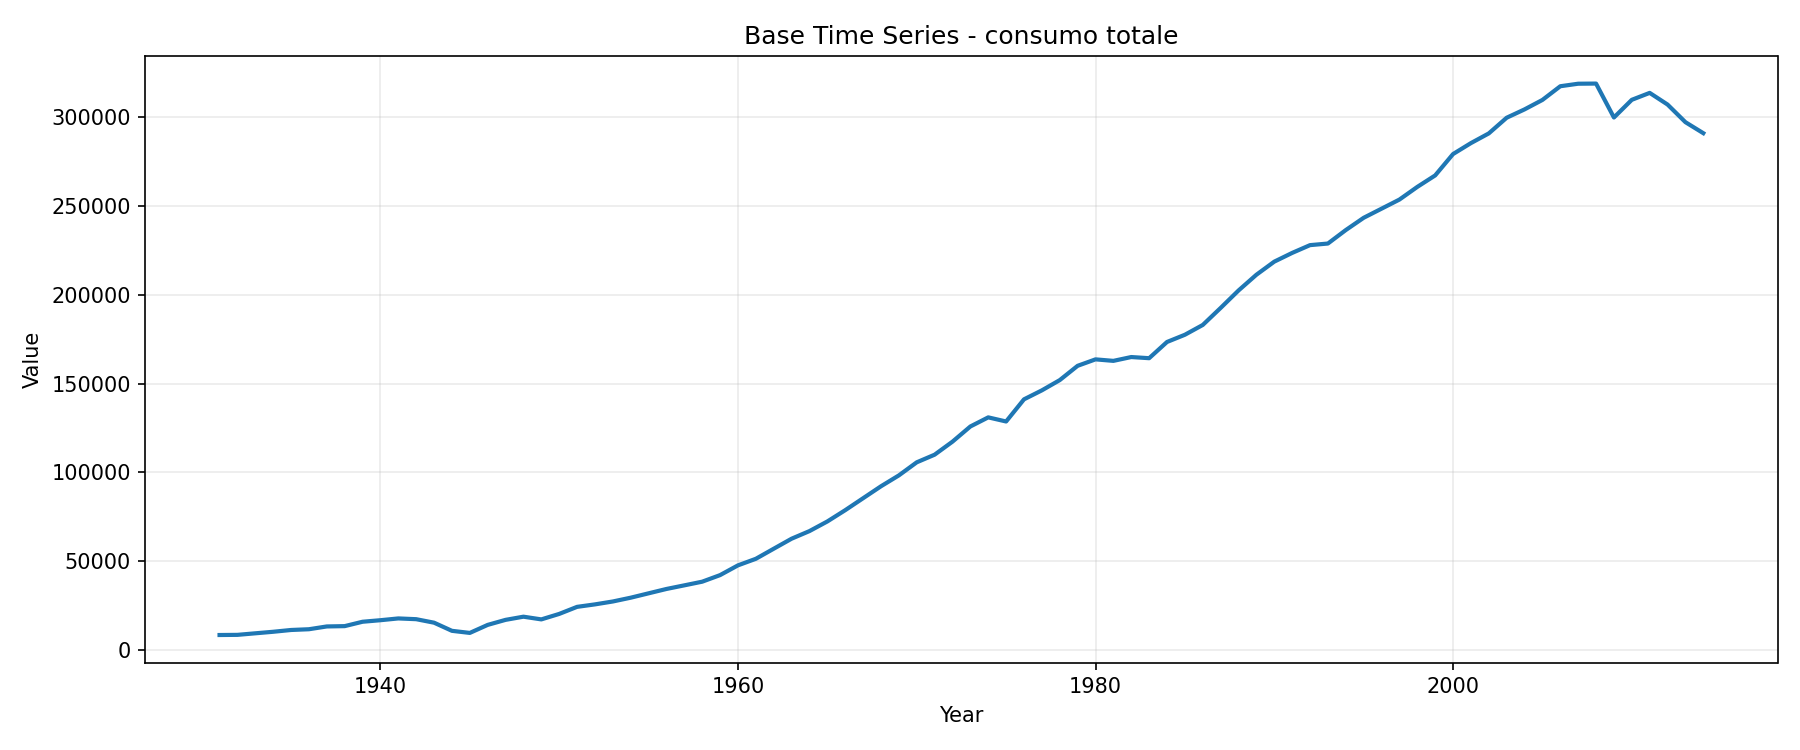

### Plot - Frequency Distribution

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\frequency_distribution.png

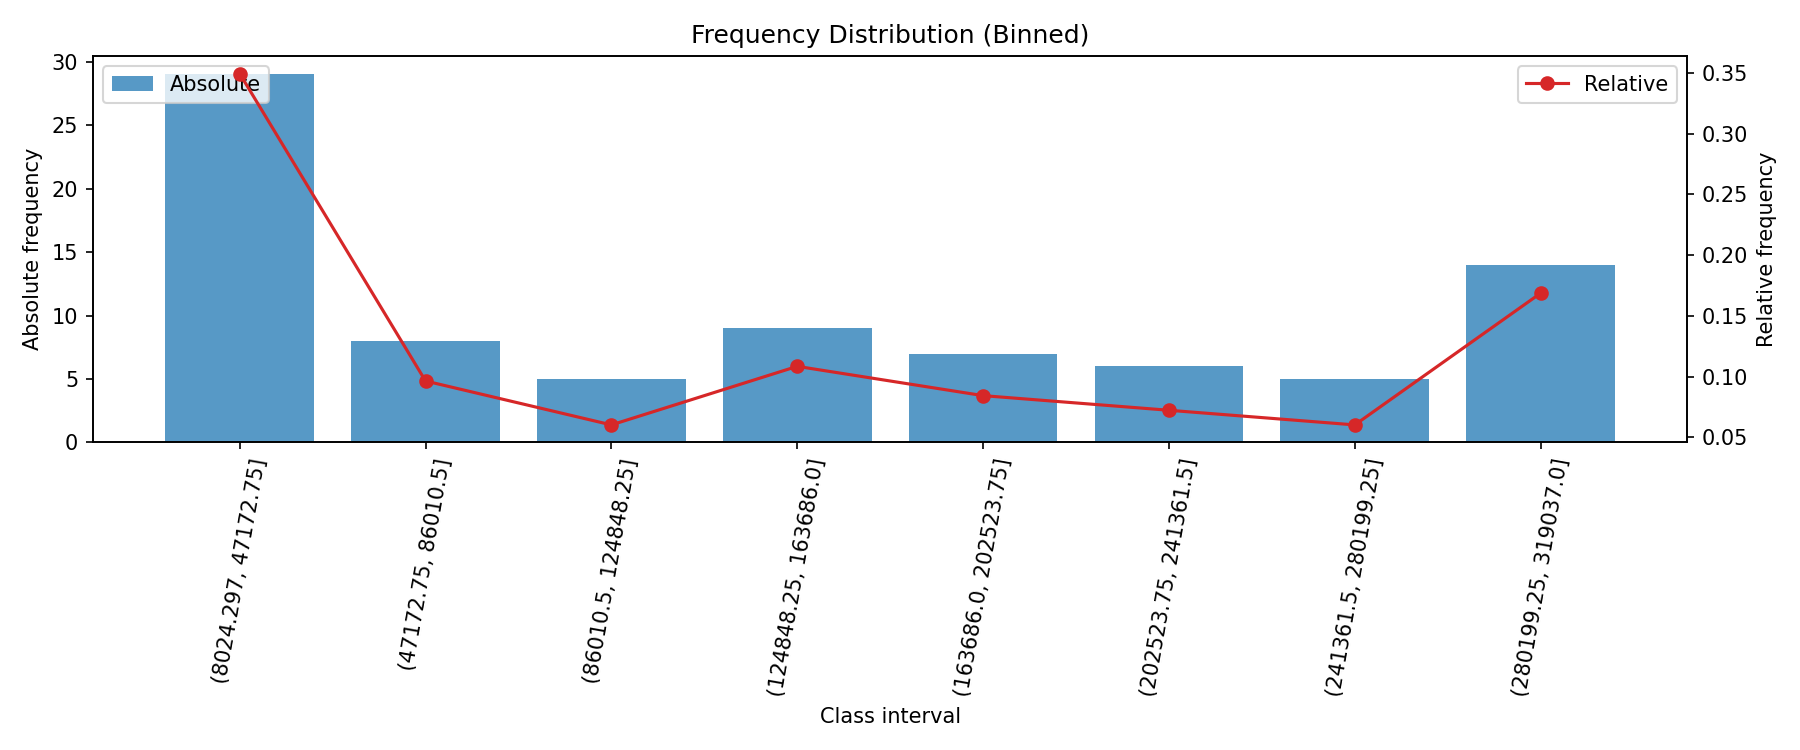

### Plot - Density Comparison

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\density_comparison.png

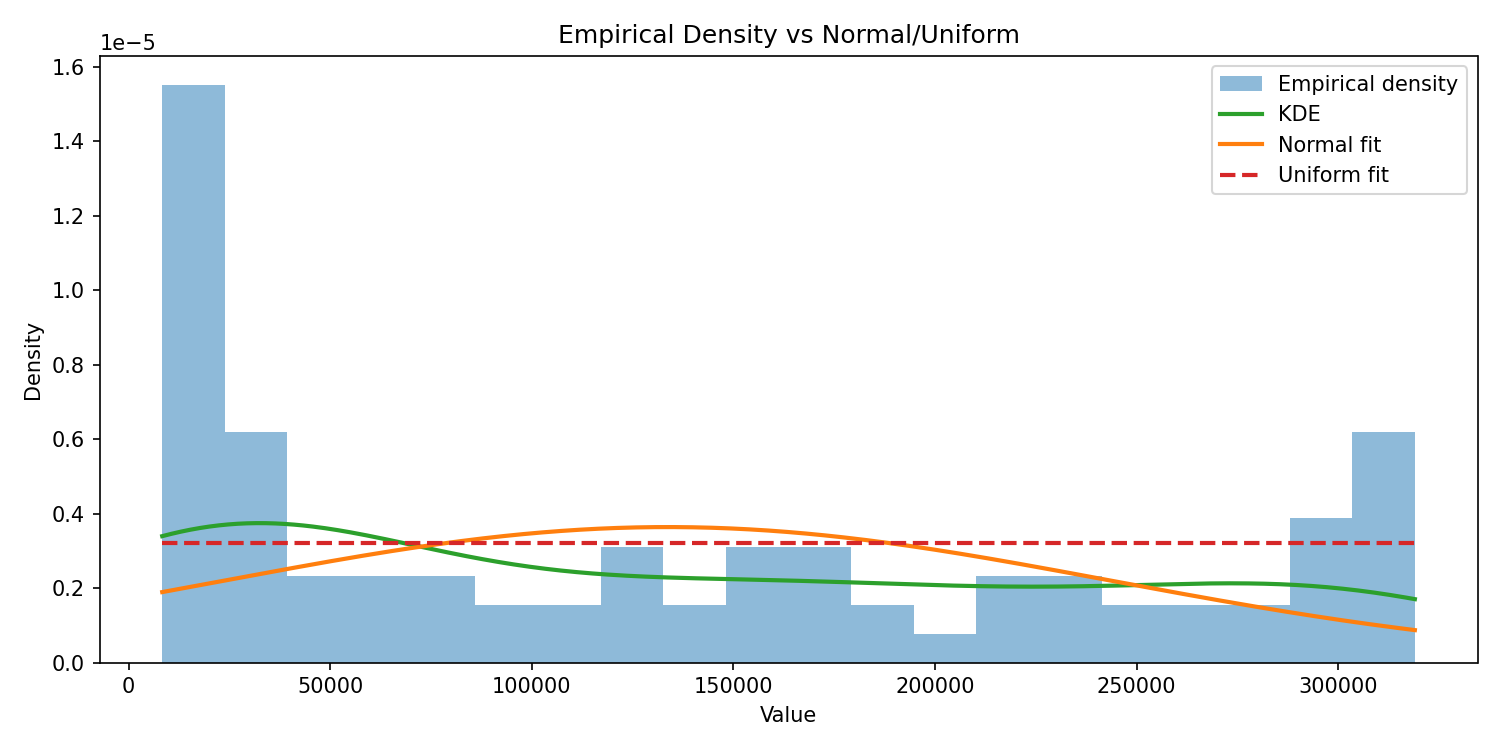

### Plot - Discrete Distribution

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\discrete_distribution.png

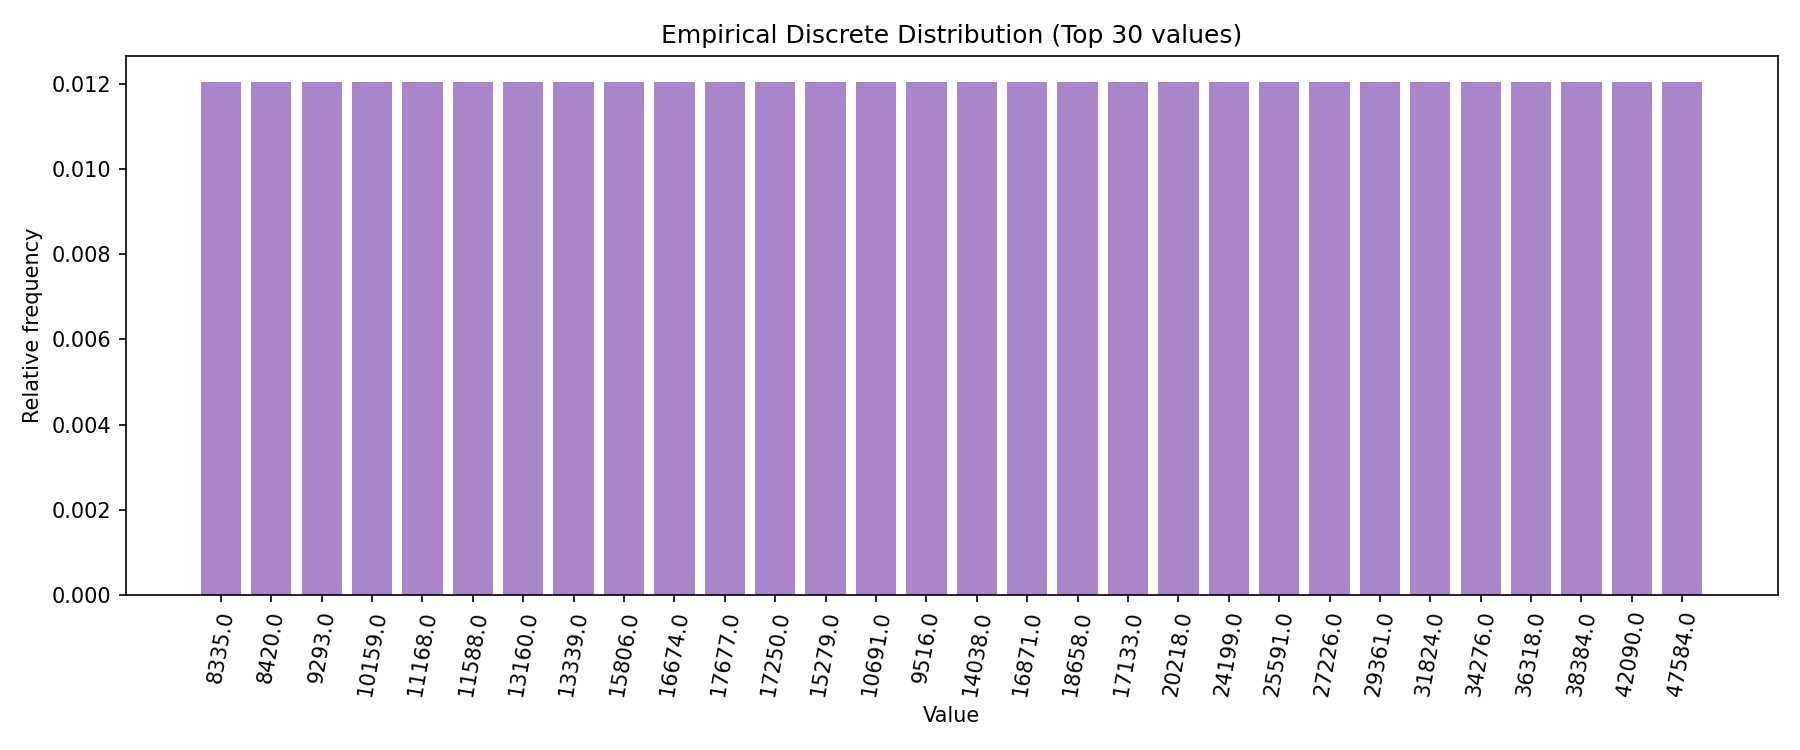

### Plot - Global Outliers Boxplot

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\global_outliers_boxplot.png

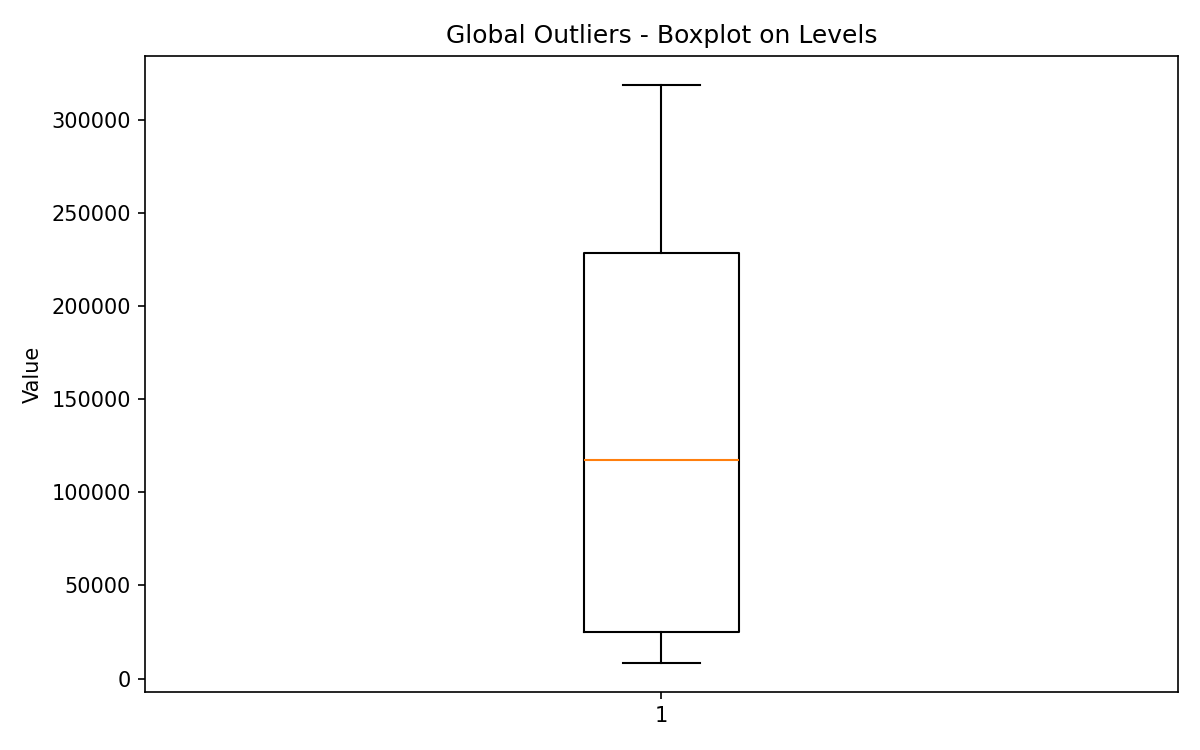

### Plot - Outliers Qqplot

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\outliers_qqplot.png

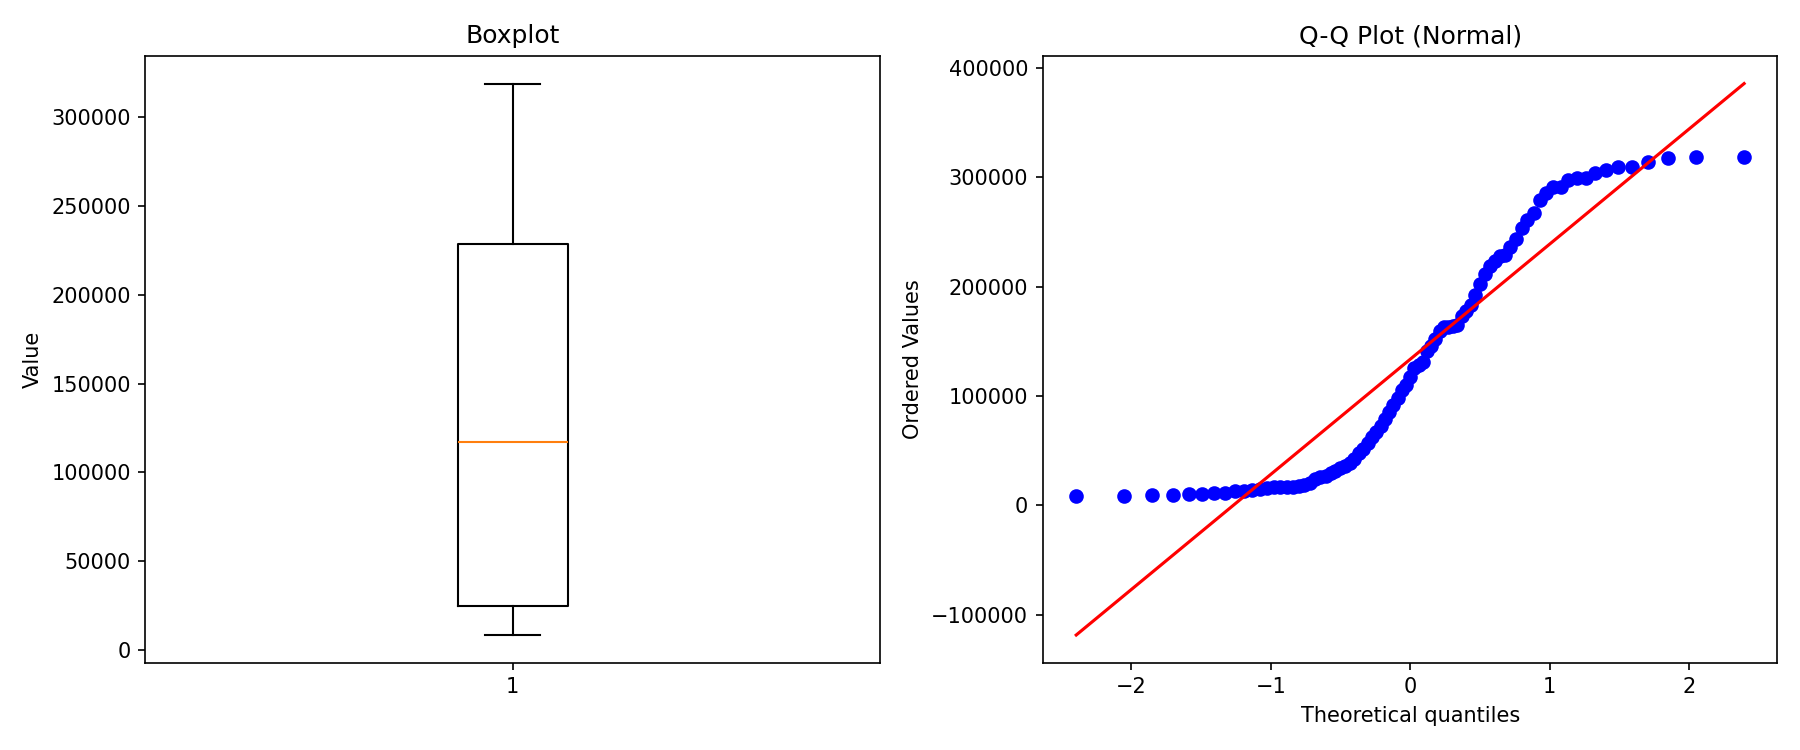

### Plot - Trend Validation

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\trend_validation.png

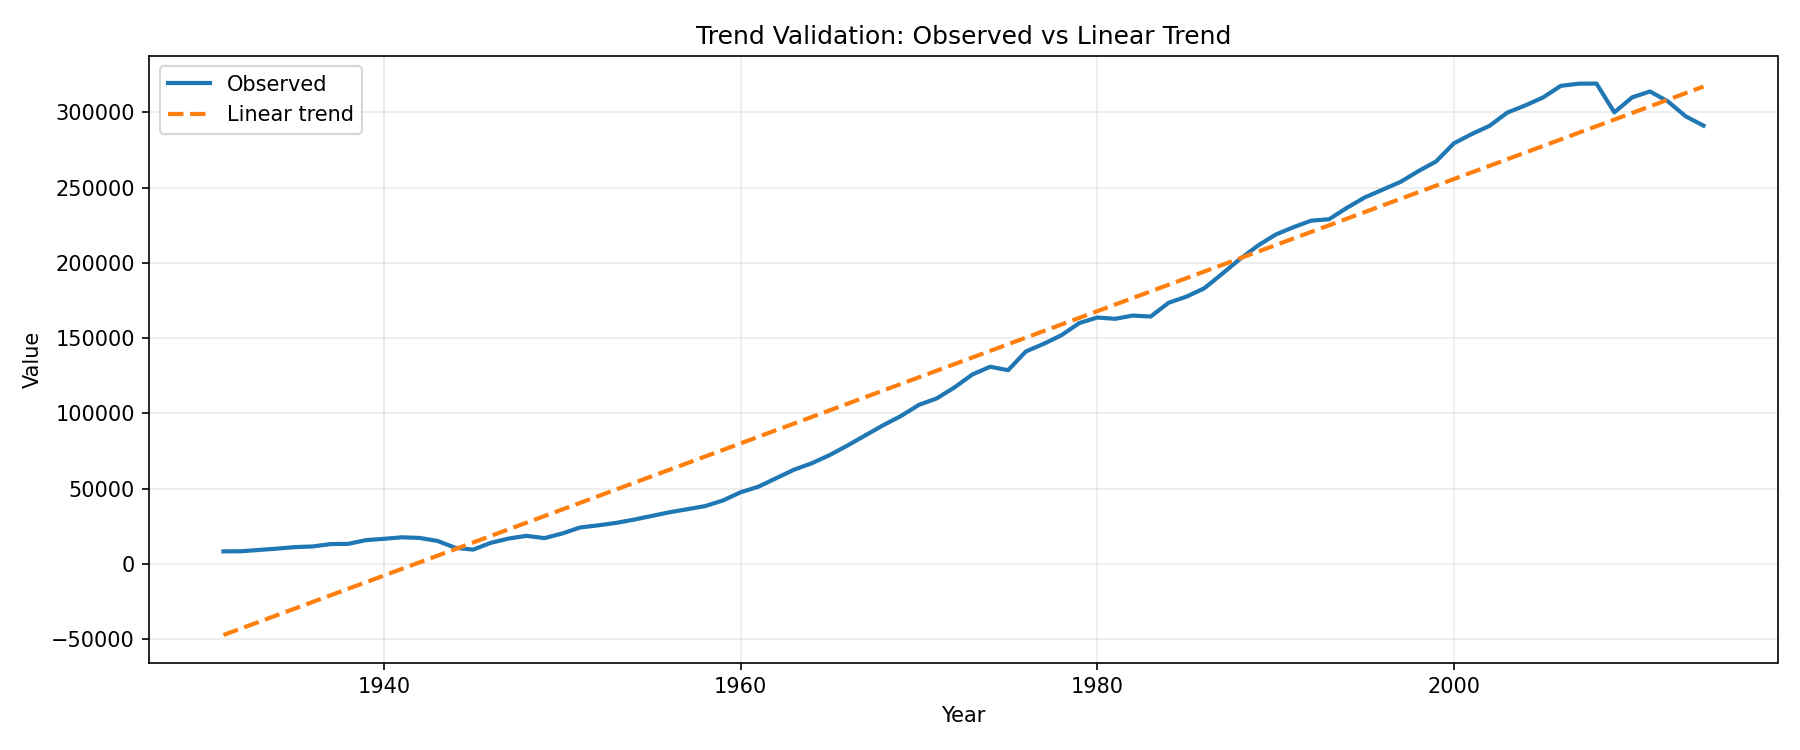

### Plot - Local Outliers Yoy

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\local_outliers_yoy.png

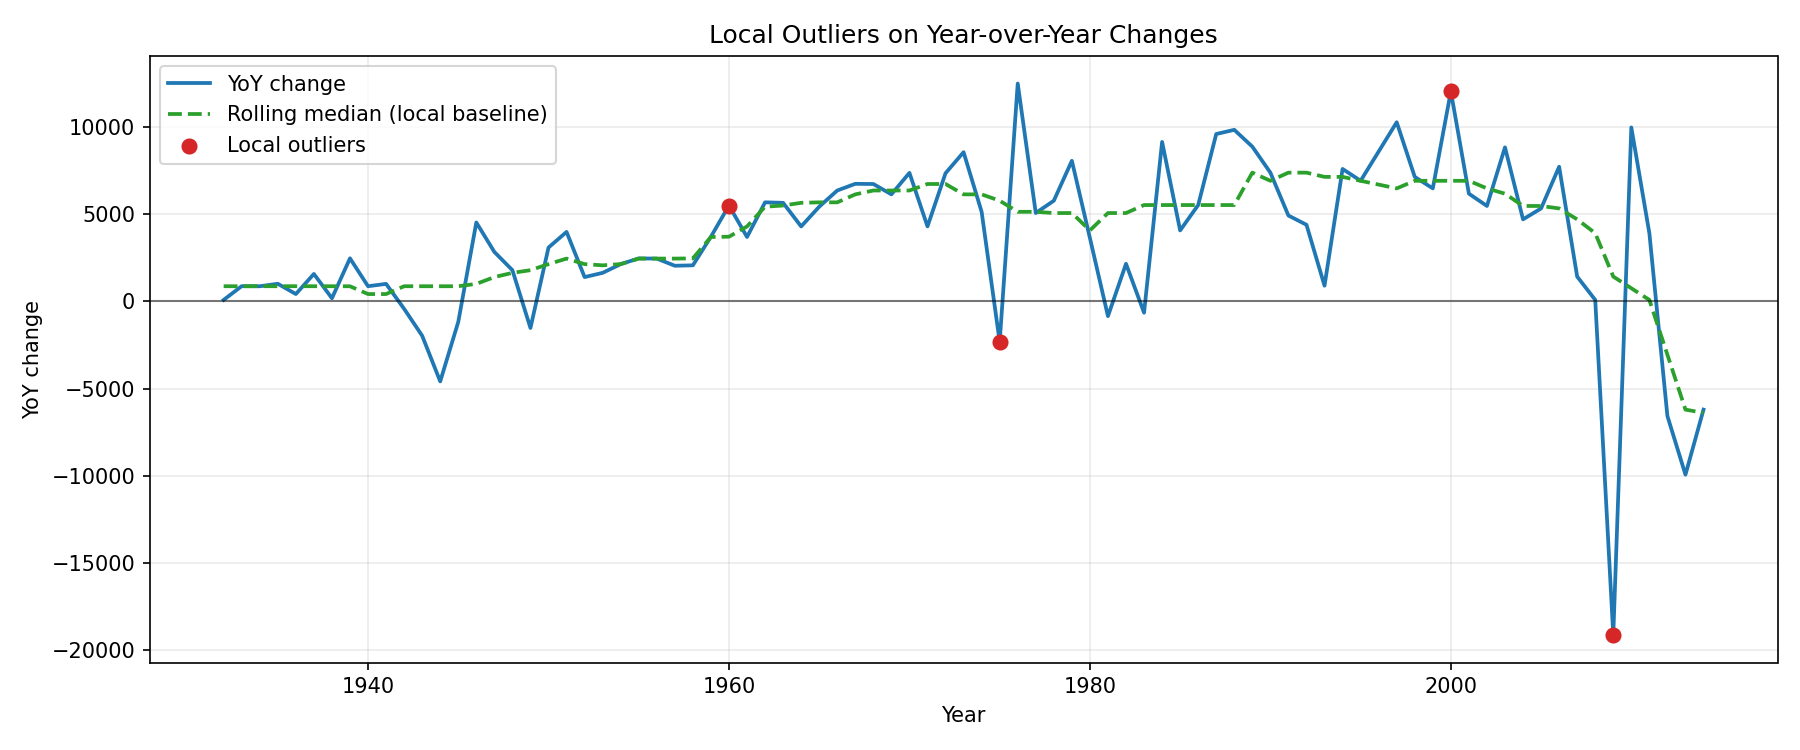

### Plot - Local Outliers Boxplot

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\descriptive\local_outliers_boxplot.png

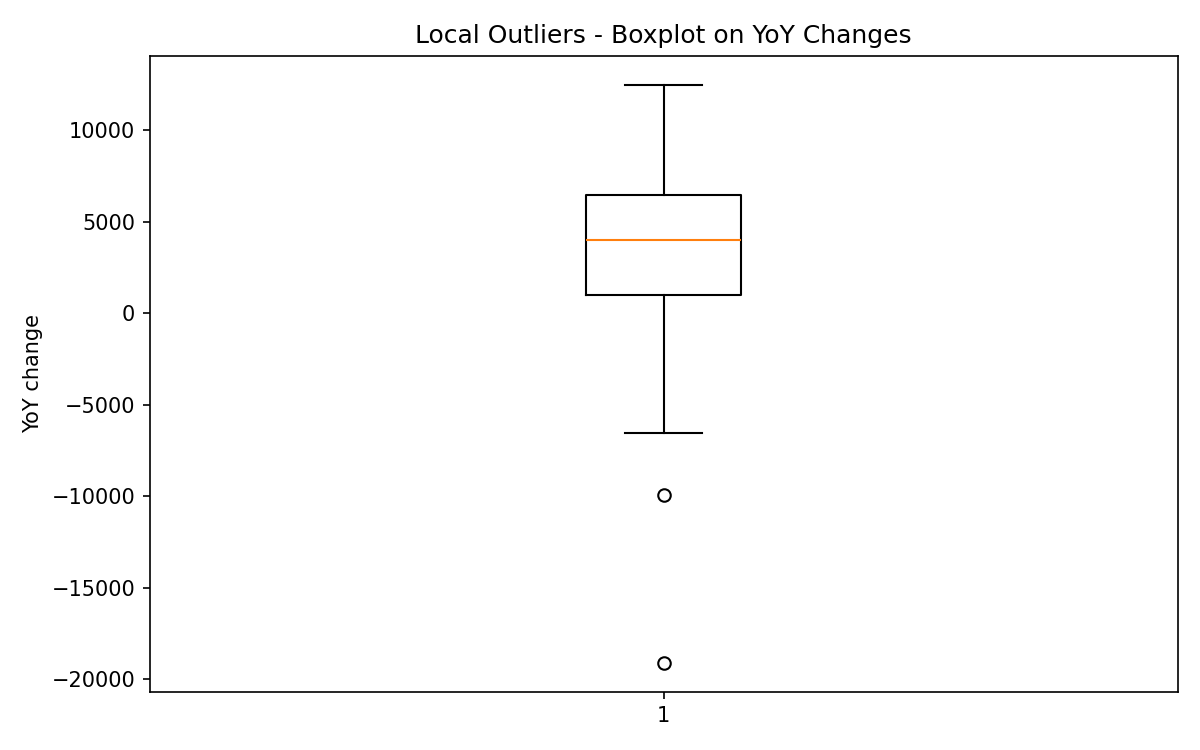

In [15]:
_log("Step 1: visualizzazione output descrittiva")

descriptive_files = [
    METRICS / "descriptive" / "series_clean.csv",
    METRICS / "descriptive" / "frequency_distribution.csv",
    METRICS / "descriptive" / "central_tendency.csv",
    METRICS / "descriptive" / "dispersion_measures.csv",
    METRICS / "descriptive" / "outliers_iqr.csv",
    METRICS / "descriptive" / "outliers_summary.csv",
    METRICS / "descriptive" / "trend_summary.csv",
    METRICS / "descriptive" / "yoy_variation_details.csv",
    METRICS / "descriptive" / "local_outliers_yoy.csv",
    METRICS / "descriptive" / "local_outliers_summary.csv",
    PLOTS / "descriptive" / "series_base.png",
    PLOTS / "descriptive" / "frequency_distribution.png",
    PLOTS / "descriptive" / "density_comparison.png",
    PLOTS / "descriptive" / "discrete_distribution.png",
    PLOTS / "descriptive" / "global_outliers_boxplot.png",
    PLOTS / "descriptive" / "outliers_qqplot.png",
    PLOTS / "descriptive" / "trend_validation.png",
    PLOTS / "descriptive" / "local_outliers_yoy.png",
    PLOTS / "descriptive" / "local_outliers_boxplot.png",
]

_show_artifact_group("Output Step 1 - Descrittiva", descriptive_files)

## Step 2 - Preprocessing e selezione configurazione

[2026-03-31 00:12:32] Step 2: visualizzazione output preprocessing


## Output Step 2 - Preprocessing

### Tabella - Split Summary

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\preprocessing\split_summary.csv

- Shape: 3 righe x 4 colonne

...

- File: C:\Users\giann\Documents\GitHub\FinalProject\Datasets\processed\ConsumptionTotal\preprocessed_test_v1.csv

- Shape: 13 righe x 2 colonne

,year,value
0,2002,0.018972
1,2003,0.029893
2,2004,0.015559
3,2005,0.017343
4,2006,0.024600
5,2007,0.004462
6,2008,0.000263
7,2009,-0.061808
8,2010,0.032702
9,2011,0.012529


### Plot - Raw Vs Transformed

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\preprocessing\raw_vs_transformed.png

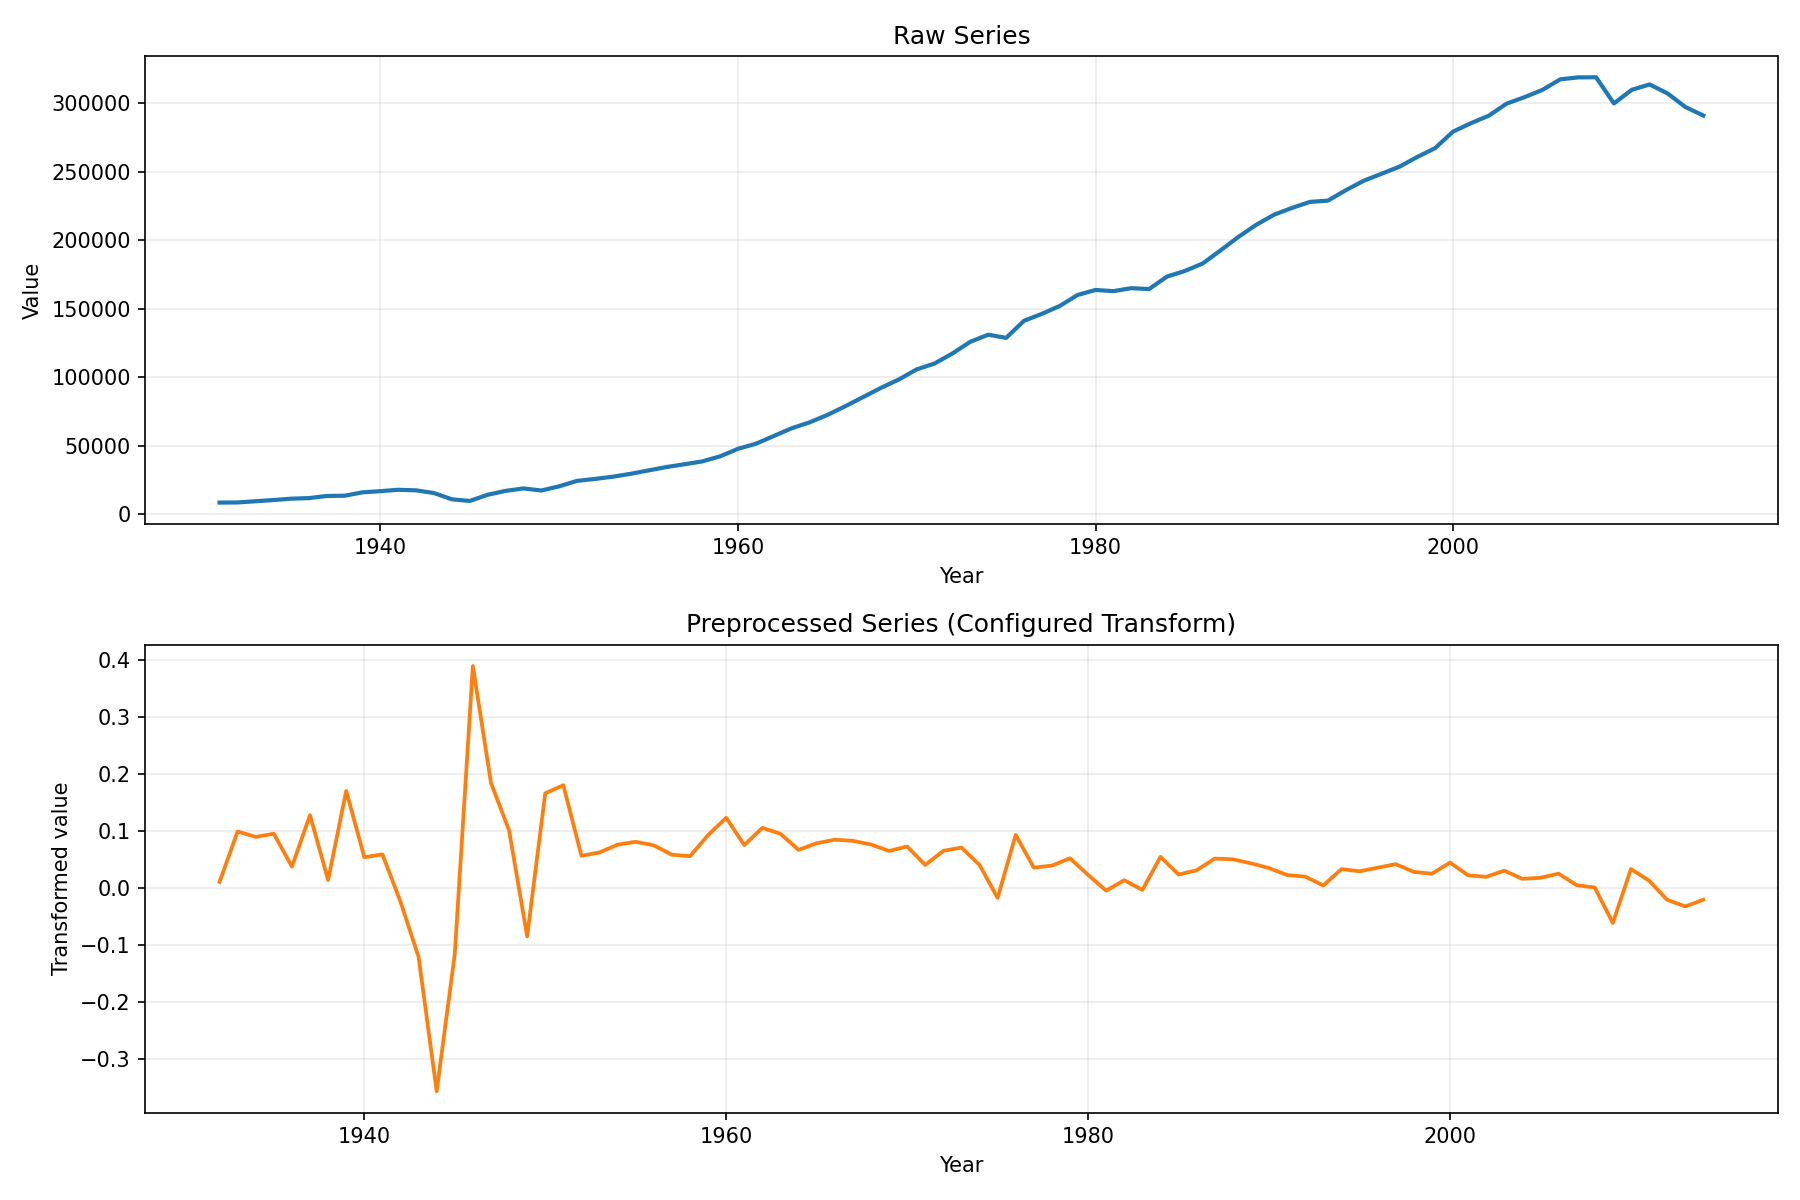

### Plot - Split View

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\preprocessing\split_view.png

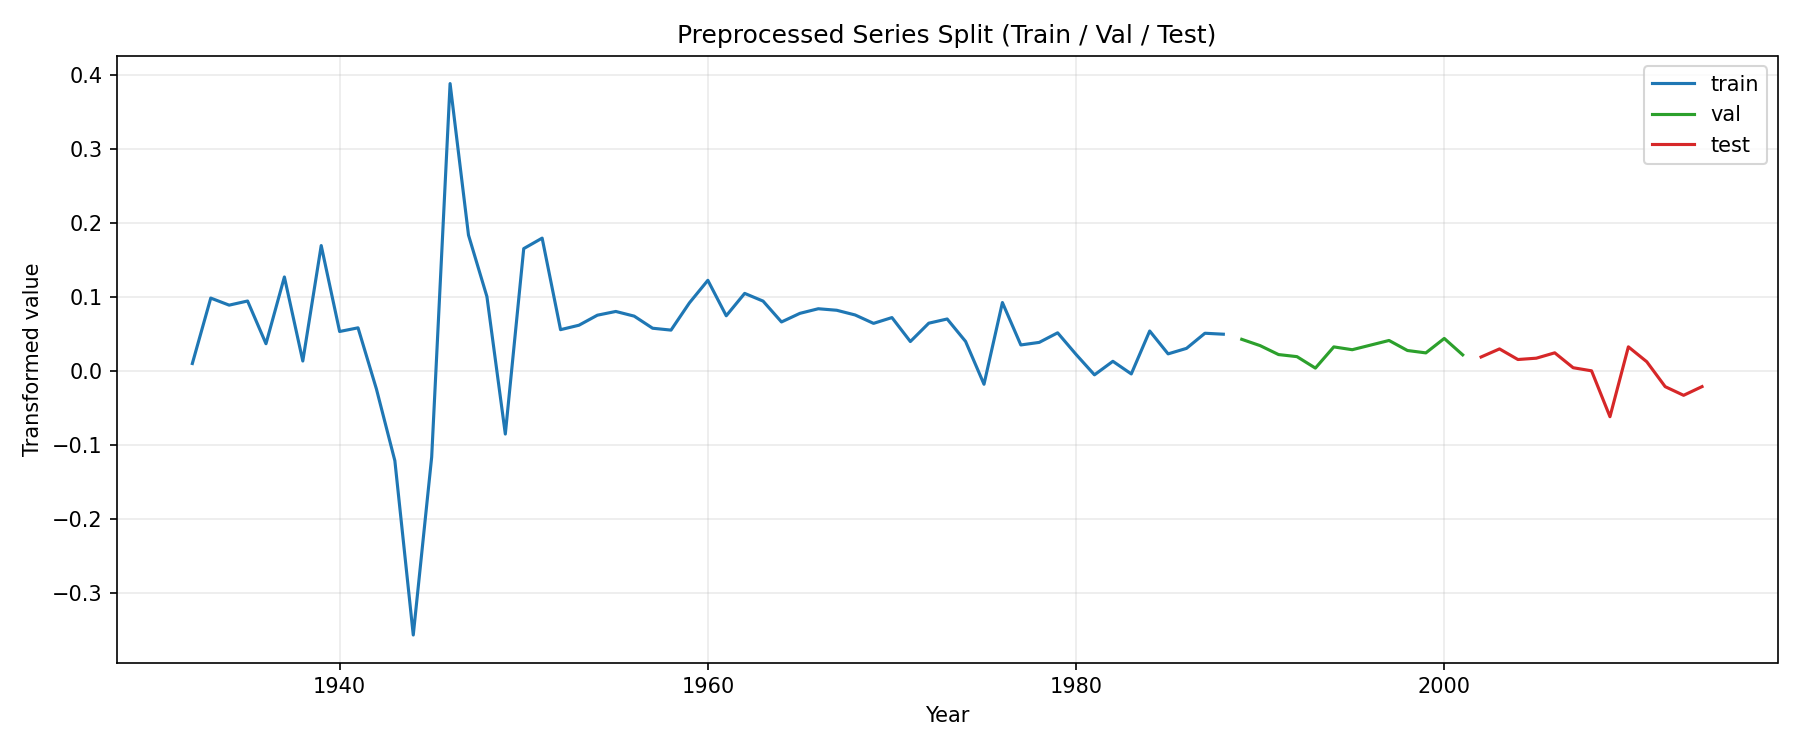

### Plot - Acf Pacf

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\preprocessing\acf_pacf.png

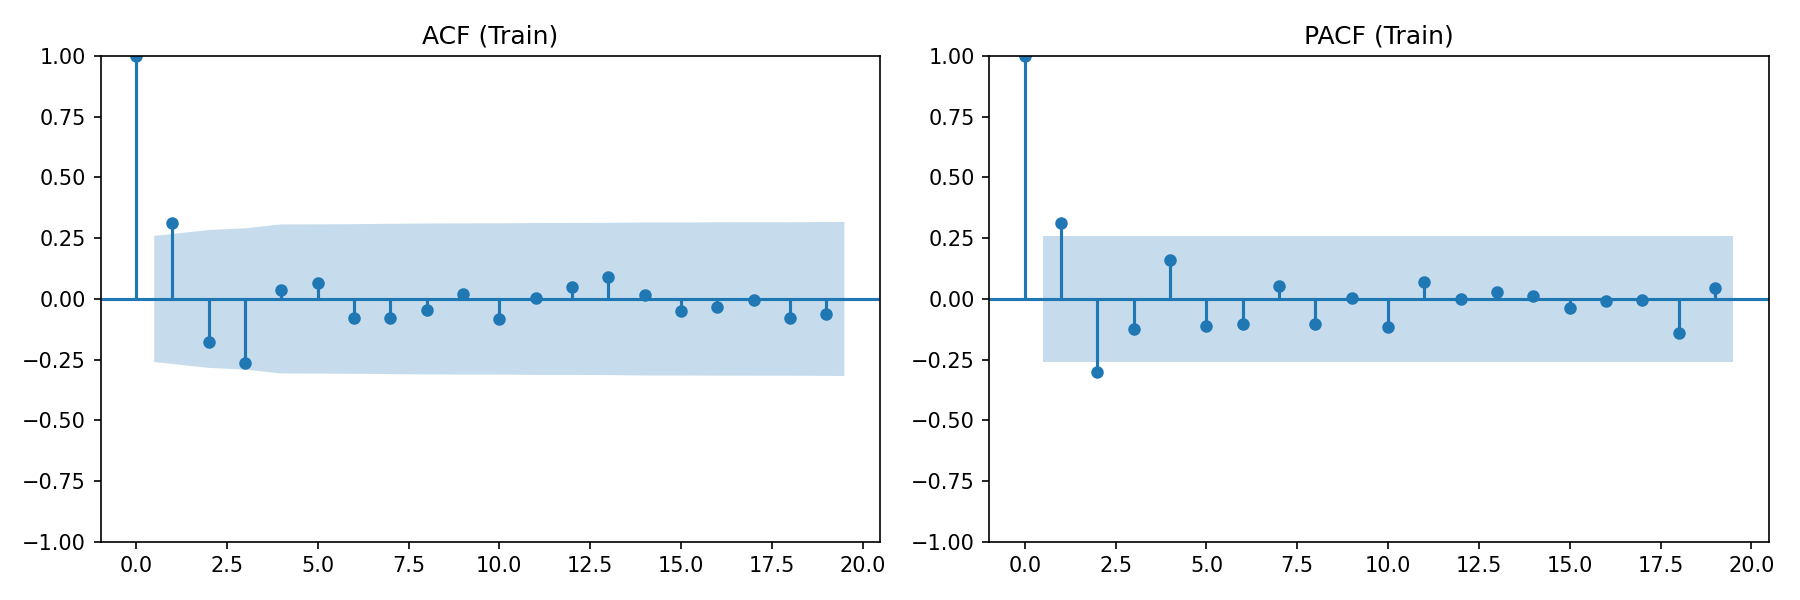

### Plot - Local Outliers

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\preprocessing\local_outliers.png

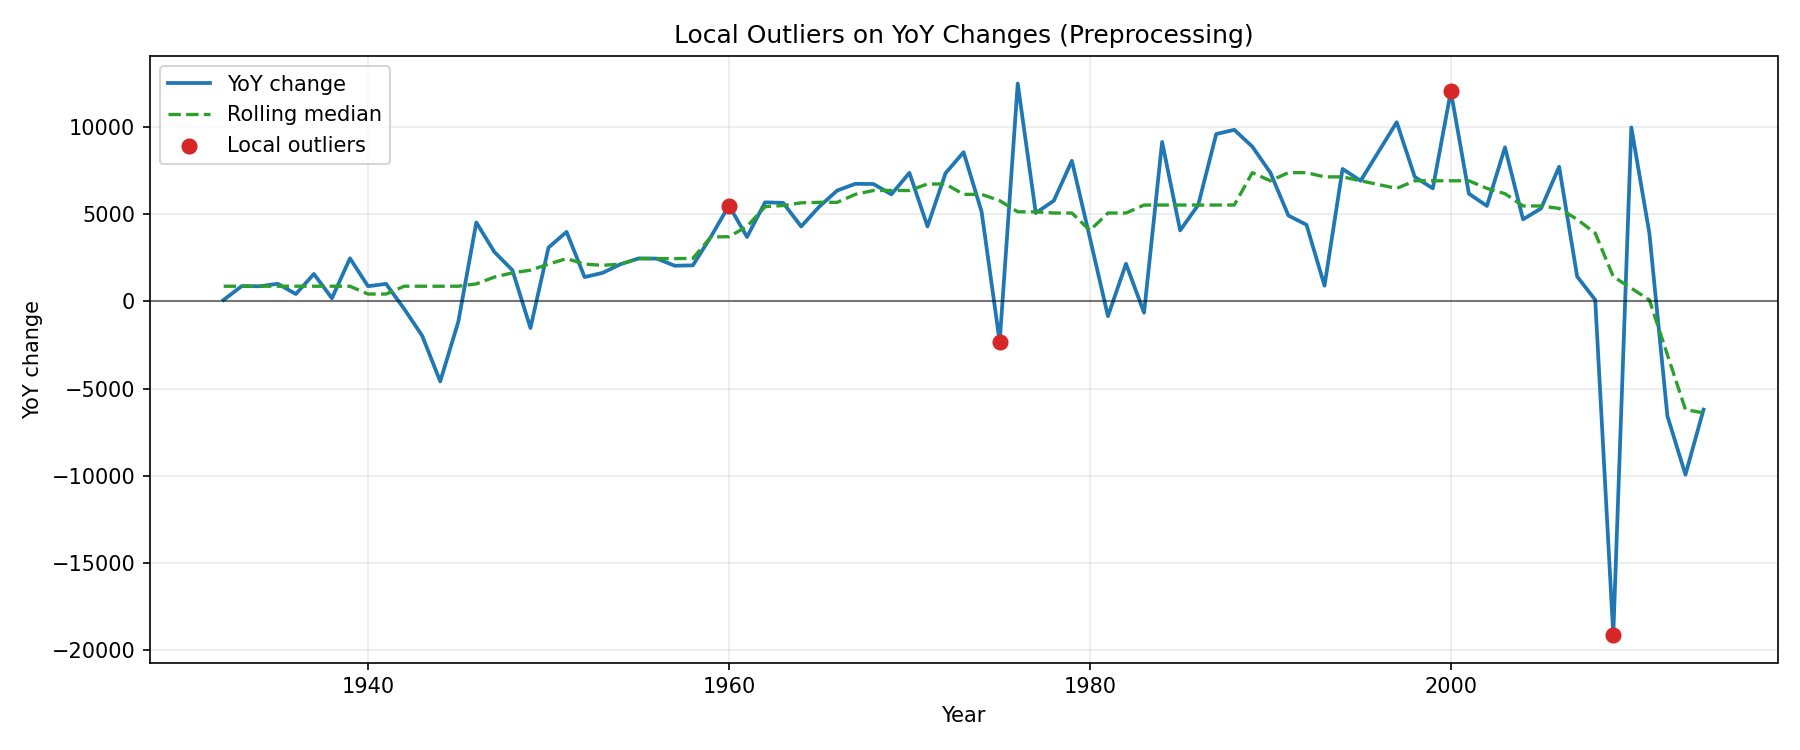

In [16]:
_log("Step 2: visualizzazione output preprocessing")

preprocessing_files = [
    METRICS / "preprocessing" / "split_summary.csv",
    METRICS / "preprocessing" / "tests.csv",
    METRICS / "preprocessing" / "local_outliers.csv",
    METRICS / "preprocessing" / "candidate_tests.csv",
    METRICS / "preprocessing" / "candidate_backtest.csv",
    ARTIFACTS / "preprocessing" / "selected_config.json",
    PROCESSED / "preprocessed_train_v1.csv",
    PROCESSED / "preprocessed_val_v1.csv",
    PROCESSED / "preprocessed_test_v1.csv",
    PLOTS / "preprocessing" / "raw_vs_transformed.png",
    PLOTS / "preprocessing" / "split_view.png",
    PLOTS / "preprocessing" / "acf_pacf.png",
    PLOTS / "preprocessing" / "local_outliers.png",
]

_show_artifact_group("Output Step 2 - Preprocessing", preprocessing_files)

## Step 3 - Modelli statistici

[2026-03-31 00:12:32] Step 3: visualizzazione output statistico


## Output Step 3 - Statistical

### Tabella - Sarima Grid

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\statistical\sarima_grid.csv

- Shape: 18 righe x 17 colonne

...

### Artifact - Winner Params

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\artifacts\statistical\winner_params.json

,value
model,sarima
best_params,"{'order': (2, 0, 2), 'seasonal_order': (0, 0, ..."
rmse_val,0.013002
mae_val,0.010281
mape_val,97.815859
mbe_val,0.0071
abs_mbe_val,0.0071
rmse_val_orig,16675.810025
mae_val_orig,14295.104546
mape_val_orig,5.589321


### Plot - Forecast Comparison

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\statistical\forecast_comparison.png

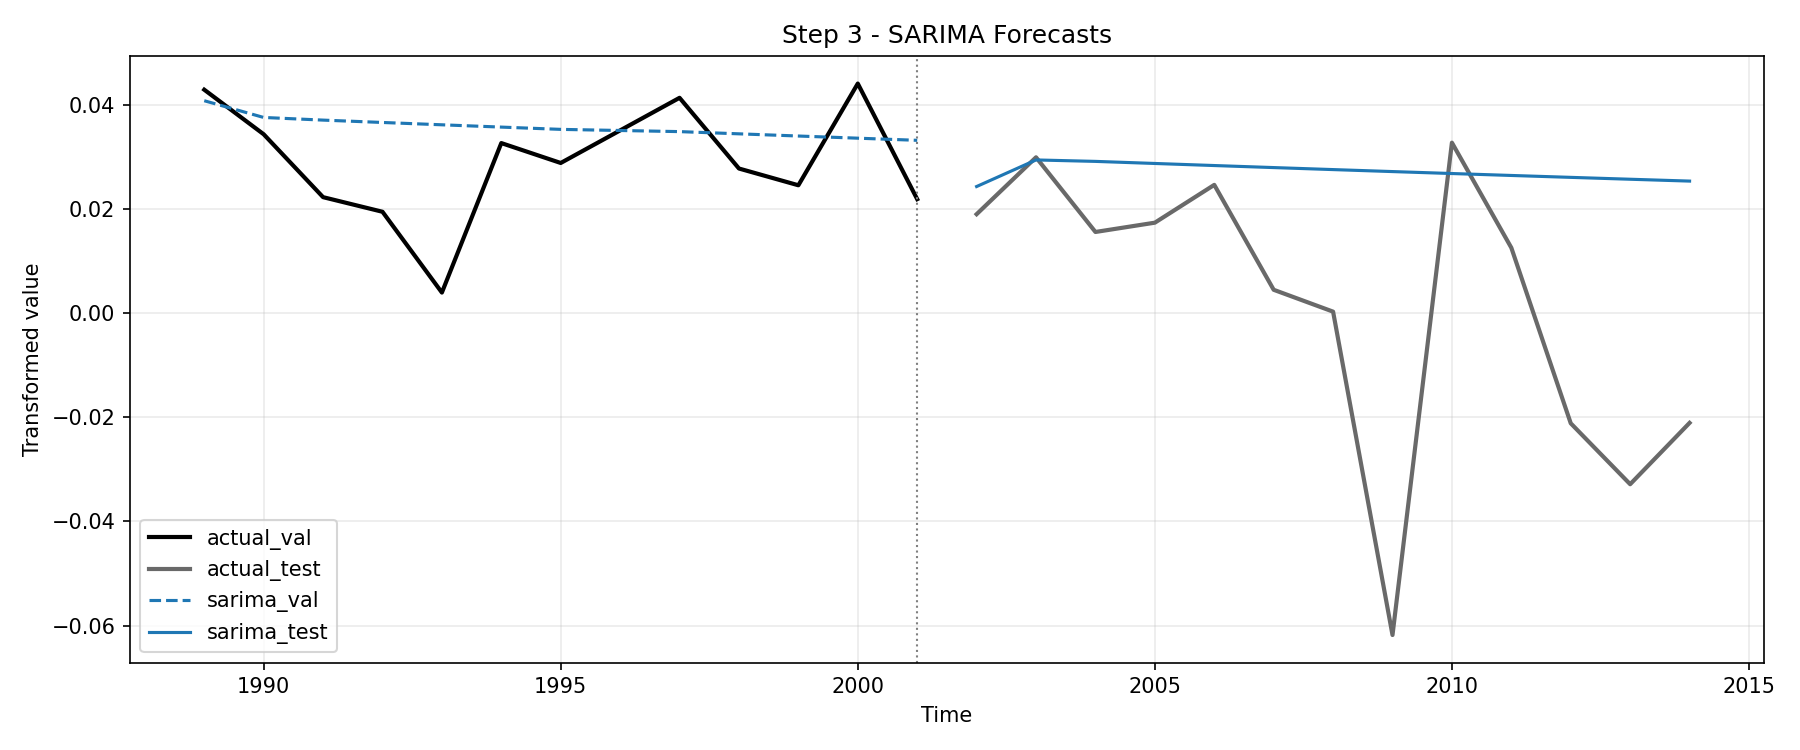

### Plot - Residuals Diagnostics

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\statistical\residuals_diagnostics.png

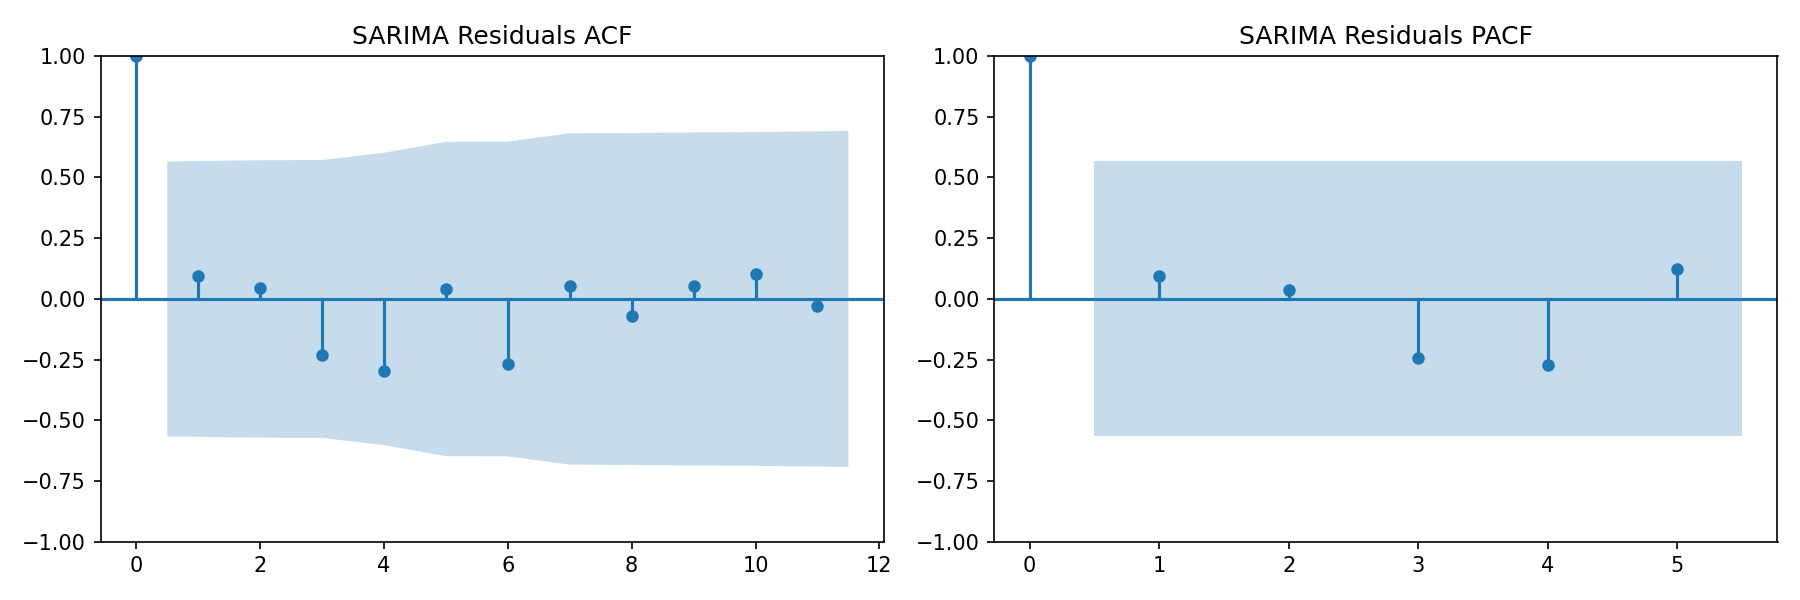

### Plot - Forecast Original Scale

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\statistical\forecast_original_scale.png

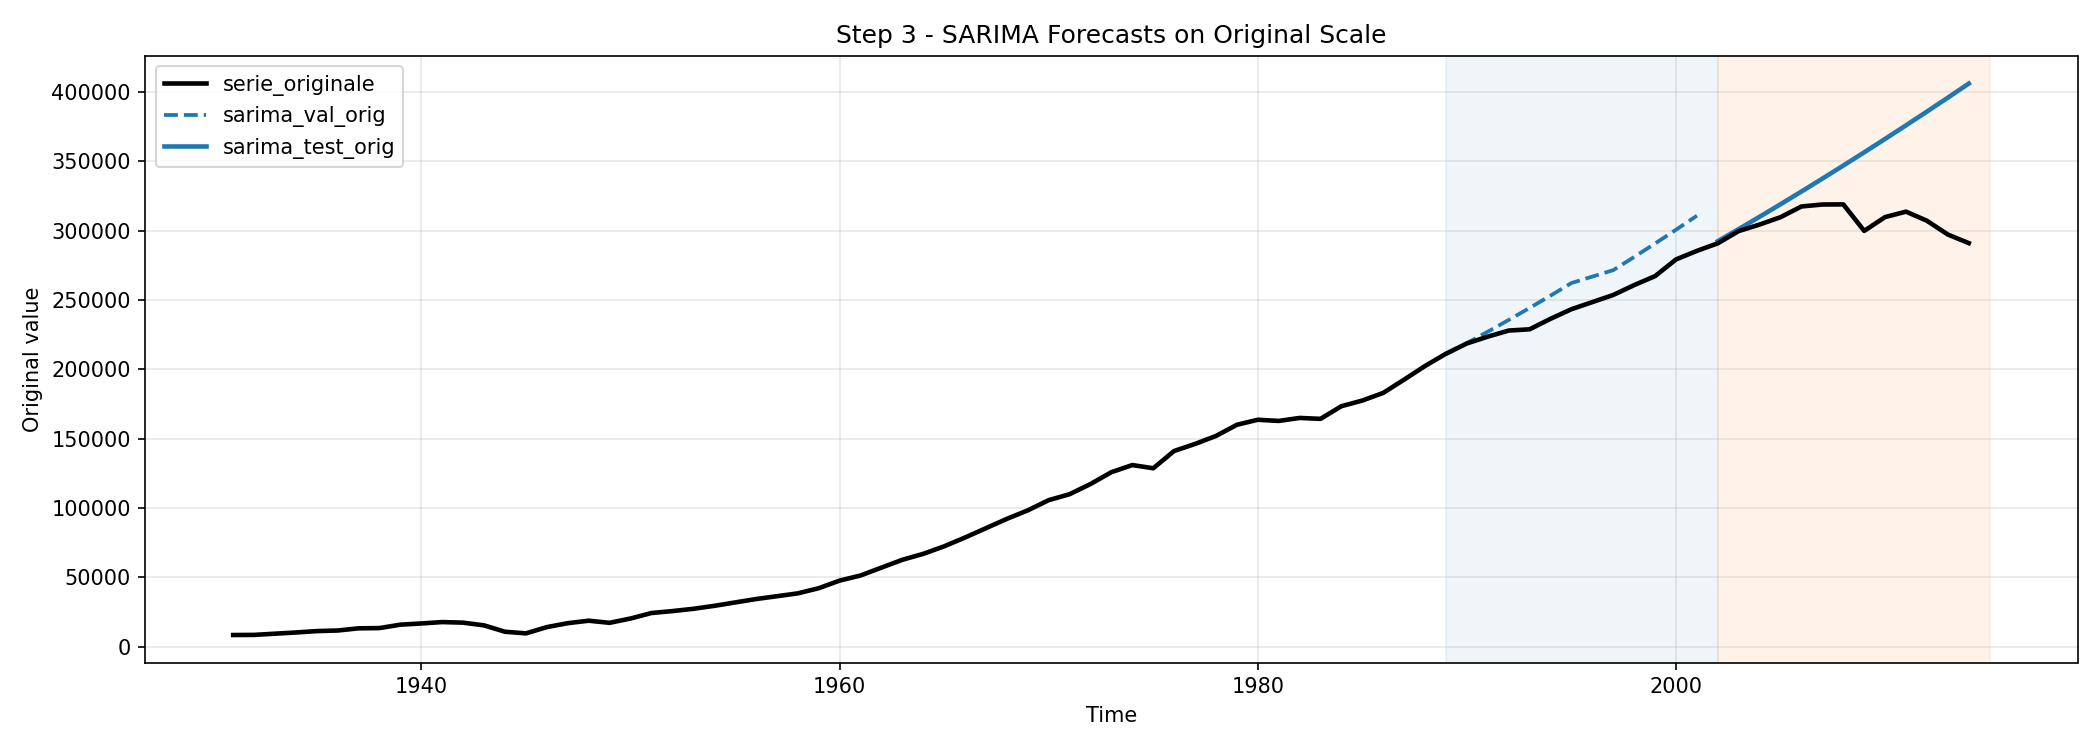

In [17]:
_log("Step 3: visualizzazione output statistico")

statistical_files = [
    METRICS / "statistical" / "sarima_grid.csv",
    METRICS / "statistical" / "summary.csv",
    METRICS / "statistical" / "residual_diagnostics.csv",
    METRICS / "statistical" / "forecasts.csv",
    ARTIFACTS / "statistical" / "winner_params.json",
    PLOTS / "statistical" / "forecast_comparison.png",
    PLOTS / "statistical" / "residuals_diagnostics.png",
    PLOTS / "statistical" / "forecast_original_scale.png",
]

_show_artifact_group("Output Step 3 - Statistical", statistical_files)

## Step 4 - Modelli machine learning

[2026-03-31 00:12:32] Step 4: visualizzazione output ML


## Output Step 4 - ML

### Tabella - Grid

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\ml\grid.csv

- Shape: 36 righe x 20 colonne

...

### Artifact - Winner Params

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\artifacts\ml\winner_params.json

,value
model,gradient_boosting
lookback,3
feature_selection,importance
selected_features,"lag_1, lag_2, lag_3"
n_selected_features,3
best_params,"{'n_estimators': 200, 'learning_rate': 0.1, 'm..."
rmse_val,0.010812
mae_val,0.008689
mape_val,77.31608
mbe_val,0.001497


### Plot - Forecast Comparison

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\ml\forecast_comparison.png

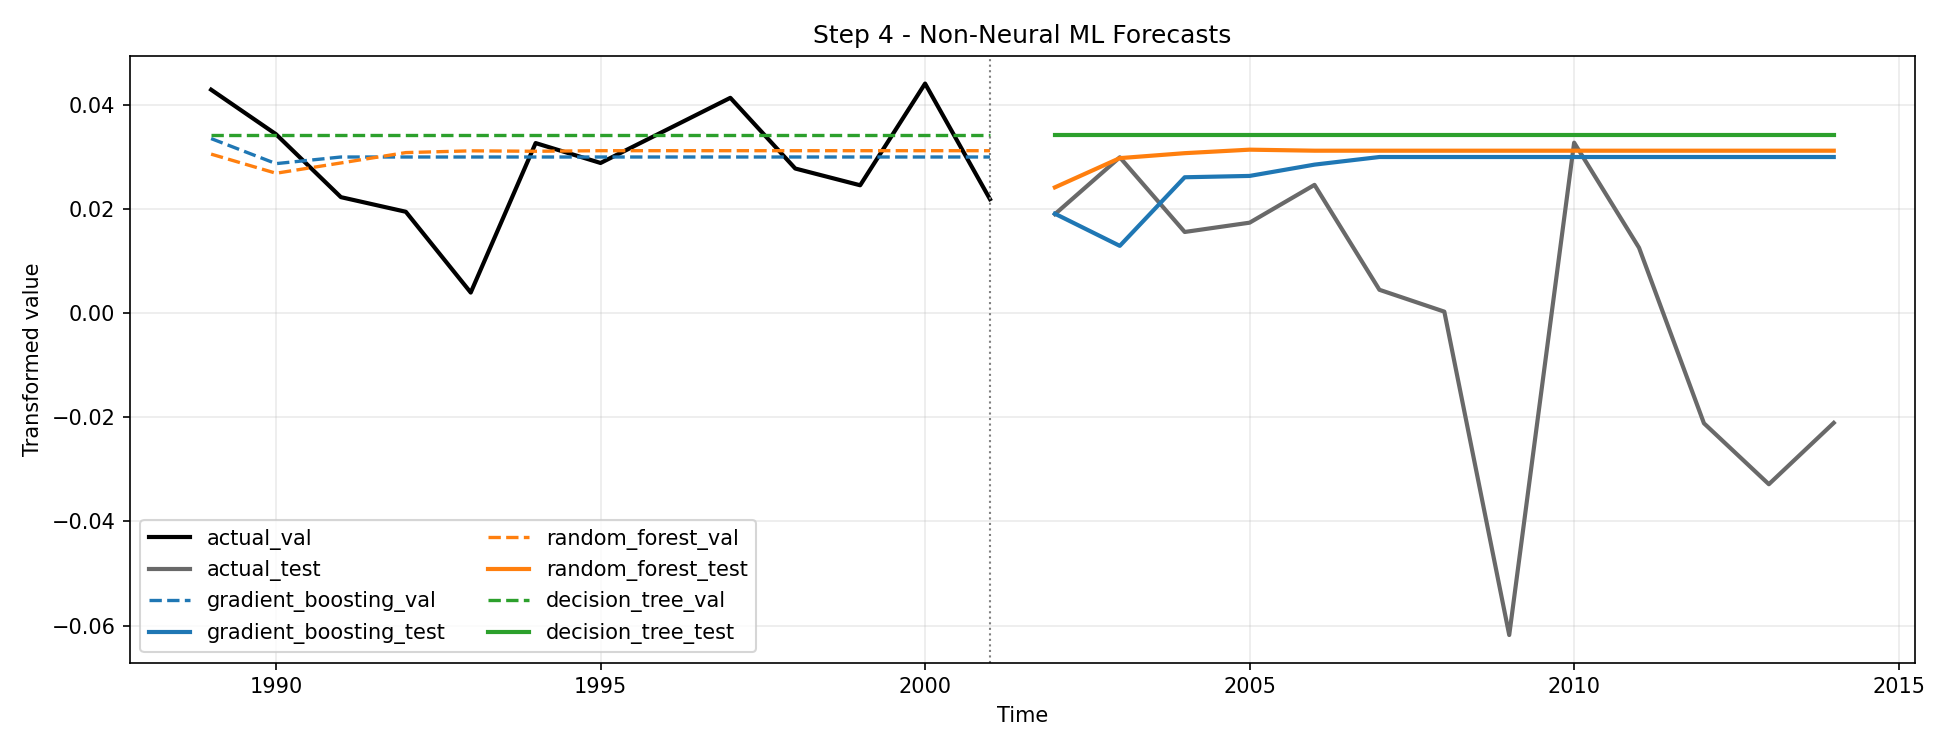

### Plot - Forecast Original Scale

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\ml\forecast_original_scale.png

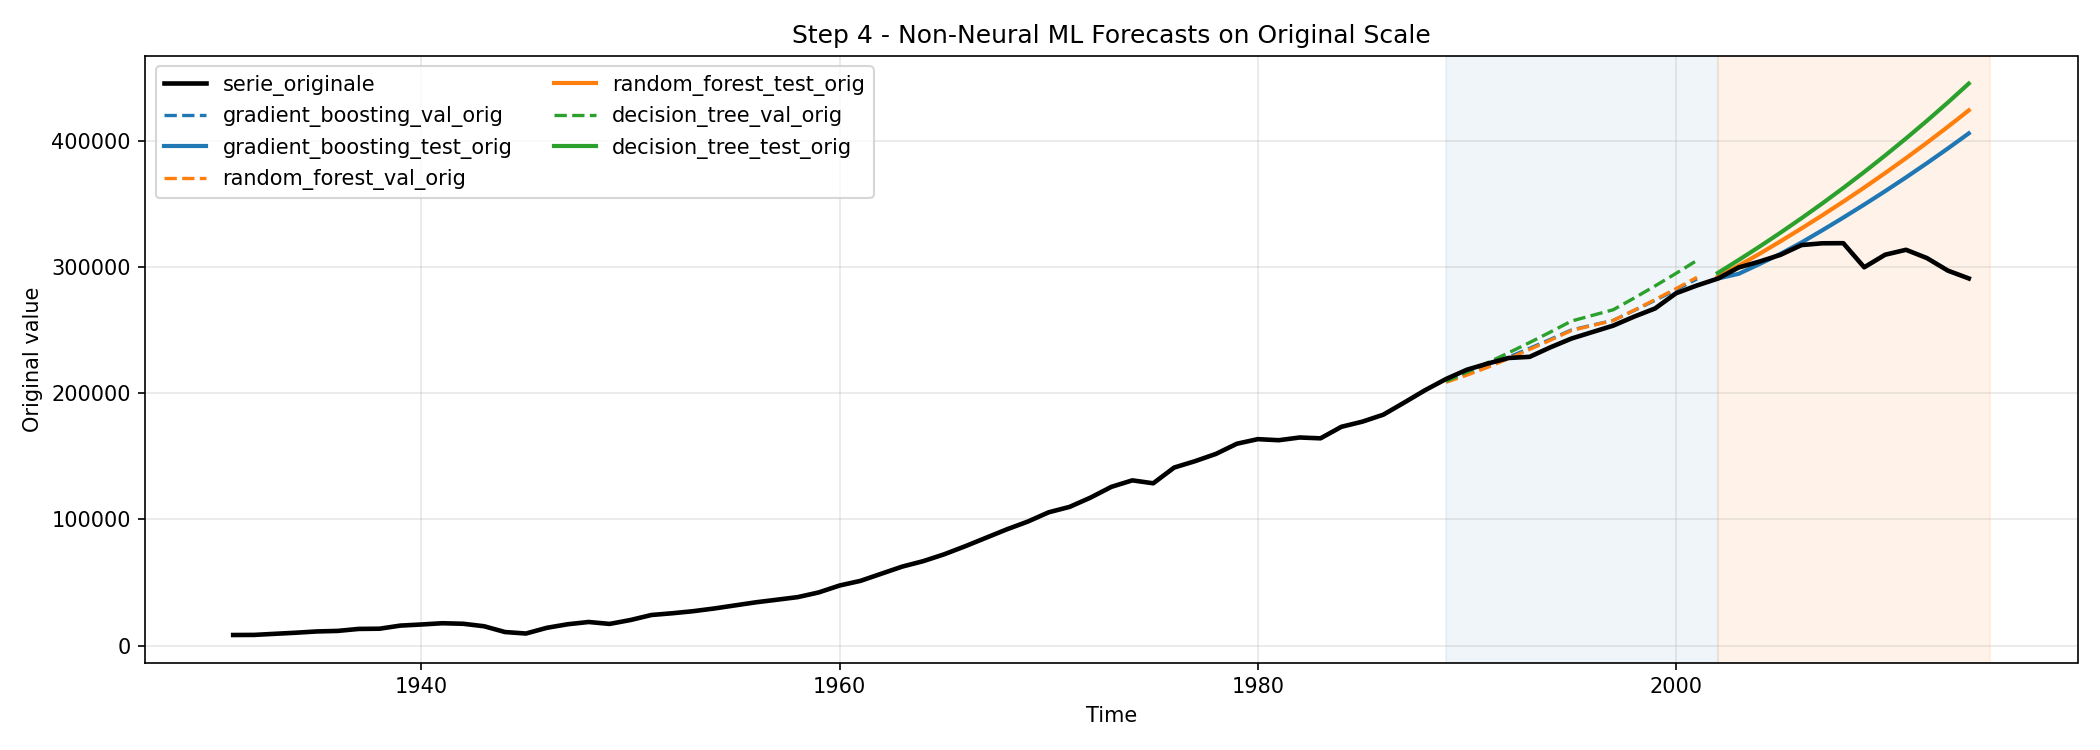

In [18]:
_log("Step 4: visualizzazione output ML")

ml_files = [
    METRICS / "ml" / "grid.csv",
    METRICS / "ml" / "summary.csv",
    METRICS / "ml" / "feature_selection.csv",
    METRICS / "ml" / "forecasts.csv",
    ARTIFACTS / "ml" / "config.json",
    ARTIFACTS / "ml" / "winner_params.json",
    PLOTS / "ml" / "forecast_comparison.png",
    PLOTS / "ml" / "forecast_original_scale.png",
]

_show_artifact_group("Output Step 4 - ML", ml_files)

## Step 4b - Stabilita ML (prima vs dopo adattamento serie corta)

In [19]:
_log("Step 4b: analisi stabilita ML con rapporto RMSE test/val")

ml_summary_path = METRICS / "ml" / "summary.csv"
if not ml_summary_path.exists():
    _show_md(f"- MANCANTE: {ml_summary_path}")
else:
    current_ml_df = pd.read_csv(ml_summary_path).copy()
    for c in ["rmse_val_orig", "rmse_test_orig", "model"]:
        if c not in current_ml_df.columns:
            raise ValueError(f"Colonna richiesta non presente in summary ML: {c}")

    current_ml_df["rmse_ratio_test_val"] = (
        current_ml_df["rmse_test_orig"] / current_ml_df["rmse_val_orig"]
    )
    current_ml_df = current_ml_df[[
        "model",
        "lookback",
        "rmse_val_orig",
        "rmse_test_orig",
        "rmse_ratio_test_val",
        "rank_rmse_val",
        "rank_rmse_test",
        "composite_score",
    ]].sort_values("rmse_ratio_test_val")

    _show_md("### Rapporto RMSE test/val (run corrente)")
    display(current_ml_df)

    baseline_rows = [
        {
            "model": "random_forest",
            "rmse_val_orig_baseline": 2283.4288759078713,
            "rmse_test_orig_baseline": 67253.40014808251,
        },
        {
            "model": "gradient_boosting",
            "rmse_val_orig_baseline": 2589.5852808772447,
            "rmse_test_orig_baseline": 59171.73219452107,
        },
        {
            "model": "decision_tree",
            "rmse_val_orig_baseline": 3516.630119957305,
            "rmse_test_orig_baseline": 55379.29893197029,
        },
    ]
    baseline_df = pd.DataFrame(baseline_rows)
    baseline_df["rmse_ratio_test_val_baseline"] = (
        baseline_df["rmse_test_orig_baseline"] / baseline_df["rmse_val_orig_baseline"]
    )

    comparison_df = baseline_df.merge(
        current_ml_df[["model", "rmse_val_orig", "rmse_test_orig", "rmse_ratio_test_val"]],
        on="model",
        how="outer",
    )
    comparison_df = comparison_df.rename(
        columns={
            "rmse_val_orig": "rmse_val_orig_current",
            "rmse_test_orig": "rmse_test_orig_current",
            "rmse_ratio_test_val": "rmse_ratio_test_val_current",
        }
    )
    if (
        "rmse_ratio_test_val_baseline" in comparison_df.columns
        and "rmse_ratio_test_val_current" in comparison_df.columns
    ):
        comparison_df["ratio_delta_current_minus_baseline"] = (
            comparison_df["rmse_ratio_test_val_current"]
            - comparison_df["rmse_ratio_test_val_baseline"]
        )

    _show_md("### Confronto baseline storico vs run corrente")
    display(comparison_df.sort_values("model"))

    if "rmse_ratio_test_val" in current_ml_df.columns:
        best_ratio_row = current_ml_df.sort_values("rmse_ratio_test_val").iloc[0]
        _show_md(
            "- Miglior stabilita nel run corrente: "
            f"**{best_ratio_row['model']}** con ratio "
            f"**{best_ratio_row['rmse_ratio_test_val']:.2f}x**."
        )

[2026-03-31 00:12:32] Step 4b: analisi stabilita ML con rapporto RMSE test/val


### Rapporto RMSE test/val (run corrente)

,model,lookback,rmse_val_orig,rmse_test_orig,rmse_ratio_test_val,rank_rmse_val,rank_rmse_test,composite_score
2,decision_tree,4,12352.727436,76998.673771,6.233334,12352.727436,76998.673771,44675.700603
0,gradient_boosting,3,4731.777269,53449.223597,11.295803,4731.777269,53449.223597,29090.500433
1,random_forest,4,4910.407950,64760.239126,13.188362,4910.407950,64760.239126,34835.323538


### Confronto baseline storico vs run corrente

,model,rmse_val_orig_baseline,rmse_test_orig_baseline,rmse_ratio_test_val_baseline,rmse_val_orig_current,rmse_test_orig_current,rmse_ratio_test_val_current,ratio_delta_current_minus_baseline
0,decision_tree,3516.630120,55379.298932,15.747832,12352.727436,76998.673771,6.233334,-9.514498
1,gradient_boosting,2589.585281,59171.732195,22.849887,4731.777269,53449.223597,11.295803,-11.554085
2,random_forest,2283.428876,67253.400148,29.452811,4910.407950,64760.239126,13.188362,-16.264449


- Miglior stabilita nel run corrente: **decision_tree** con ratio **6.23x**.

## Step 5 - Modelli neural

[2026-03-31 00:12:32] Step 5: visualizzazione output neural


## Output Step 5 - Neural

### Tabella - Grid

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\neural\grid.csv

- Shape: 60 righe x 17 colonne

...

### Artifact - Winner Params

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\artifacts\neural\winner_params.json

,value
model,mlp
lookback,4
best_params,"{'hidden_size': 8, 'activation': 'relu', 'drop..."
best_epoch,196
best_val_loss,0.020391
rmse_val,0.128207
mae_val,0.103238
mape_val,47.202329
mbe_val,-0.022608
abs_mbe_val,0.022608


### Plot - Forecast Comparison

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\neural\forecast_comparison.png

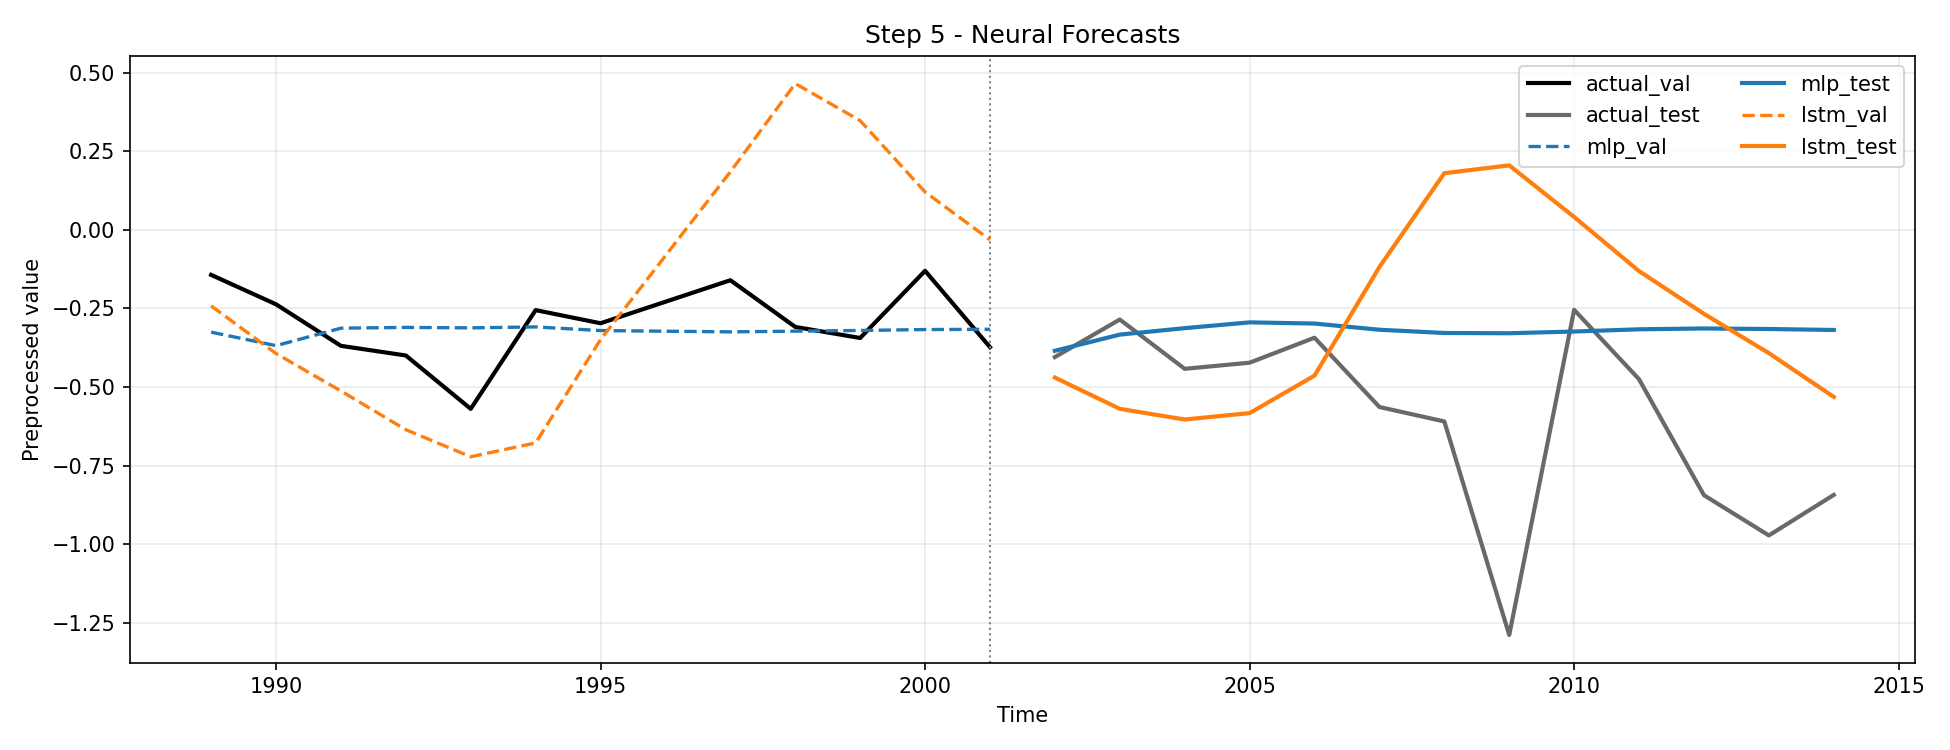

### Plot - Forecast Original Scale

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\plots\neural\forecast_original_scale.png

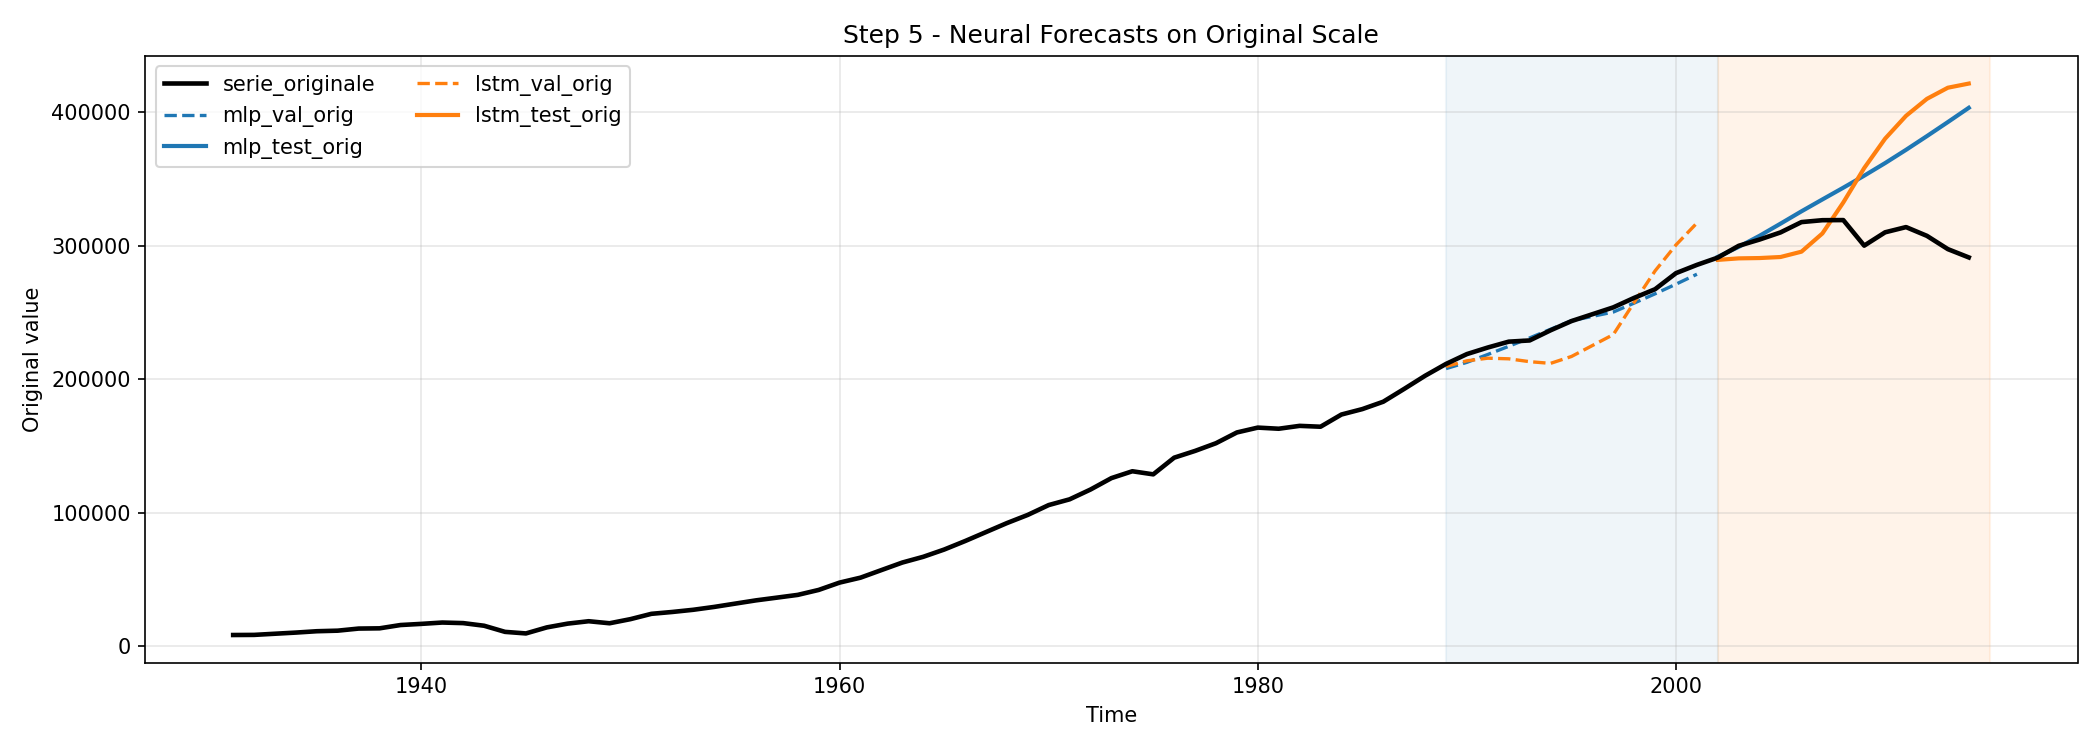

In [20]:
_log("Step 5: visualizzazione output neural")

neural_files = [
    METRICS / "neural" / "grid.csv",
    METRICS / "neural" / "summary.csv",
    METRICS / "neural" / "forecasts.csv",
    ARTIFACTS / "neural" / "config.json",
    ARTIFACTS / "neural" / "winner_params.json",
    PLOTS / "neural" / "forecast_comparison.png",
    PLOTS / "neural" / "forecast_original_scale.png",
]

_show_artifact_group("Output Step 5 - Neural", neural_files)

## Step 6-9 - Comparison, inferential, prescriptive

In [21]:
_log("Step 6-9: visualizzazione comparison, inferential, prescriptive")

comparison_files = [
    METRICS / "comparison" / "all_models.csv",
    METRICS / "comparison" / "family_winners.csv",
    METRICS / "comparison" / "winner_forecasts.csv",
    ARTIFACTS / "comparison" / "global_winner.json",
    METRICS / "inferential" / "diebold_mariano.csv",
    METRICS / "prescriptive" / "scenarios.csv",
]

_show_artifact_group("Output Step 6-9 - Comparison e analytics finali", comparison_files)

[2026-03-31 00:12:32] Step 6-9: visualizzazione comparison, inferential, prescriptive


## Output Step 6-9 - Comparison e analytics finali

### Tabella - All Models

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\comparison\all_models.csv

- Shape: 6 righe x 39 colonne

...

,family_a,family_b,loss_function,horizon,n_obs,mean_loss_diff,dm_stat,p_value,interpretation
0,statistical,ml,squared_error,1,13,2.862399e+08,3.647832,0.003340,ml_better
1,statistical,neural,squared_error,1,13,3.040762e+08,3.687113,0.003108,neural_better
2,ml,neural,squared_error,1,13,1.783626e+07,0.250459,0.806469,no_significant_difference


### Tabella - Scenarios

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\metrics\prescriptive\scenarios.csv

- Shape: 13 righe x 12 colonne

,family,model,timestamp,predicted_value,previous_observed,expected_change,expected_change_pct,uncertainty_margin,scenario_low,scenario_high,uncertainty_ratio,recommendation
0,neural,mlp,2002,291493.662074,285492.0,6001.662074,2.102217,4563.511175,286930.150899,296057.173249,0.015656,low_uncertainty_stable
1,neural,mlp,2003,299022.493109,290960.0,8062.493109,2.770997,4563.511175,294458.981933,303586.004284,0.015261,low_uncertainty_stable
2,neural,mlp,2004,307323.819018,299789.0,7534.819018,2.513374,4563.511175,302760.307843,311887.330194,0.014849,low_uncertainty_stable
3,neural,mlp,2005,316386.553750,304490.0,11896.553750,3.907043,4563.511175,311823.042574,320950.064925,0.014424,low_uncertainty_stable
4,neural,mlp,2006,325604.757614,309817.0,15787.757614,5.095833,4563.511175,321041.246439,330168.268790,0.014015,low_uncertainty_increase
5,neural,mlp,2007,334489.196288,317533.0,16956.196288,5.339979,4563.511175,329925.685112,339052.707463,0.013643,low_uncertainty_increase
6,neural,mlp,2008,343291.451687,318953.0,24338.451687,7.630733,4563.511175,338727.940512,347854.962863,0.013293,low_uncertainty_increase
7,neural,mlp,2009,352298.643568,319037.0,33261.643568,10.425638,4563.511175,347735.132392,356862.154743,0.012954,low_uncertainty_increase
8,neural,mlp,2010,361724.196660,299915.0,61809.196660,20.608905,4563.511175,357160.685484,366287.707835,0.012616,low_uncertainty_increase
9,neural,mlp,2011,371641.928314,309885.0,61756.928314,19.928983,4563.511175,367078.417138,376205.439489,0.012279,low_uncertainty_increase


## Decisioni: nostre vs automatiche

In [22]:
manual_decisions = pd.DataFrame(
    [
        {"tipo": "nostra", "decisione": "Definizione target series", "dettaglio": "target production_total da Tavola_1.14"},
        {"tipo": "nostra", "decisione": "Ordine macro del flusso", "dettaglio": "descrittiva -> preprocessing -> statistical -> ml -> neural -> evaluation"},
        {"tipo": "nostra", "decisione": "Spazio iperparametri", "dettaglio": "configurazioni candidate per SARIMA, ML e neural"},
        {"tipo": "nostra", "decisione": "Profili preprocessing", "dettaglio": "ranking distinti per statistical, ml e neural"},
        {"tipo": "nostra", "decisione": "Metriche di confronto", "dettaglio": "focus su validation per selezione winner"},
    ]
)

auto_decisions = pd.DataFrame(
    [
        {"tipo": "automatica", "decisione": "Config preprocessing vincente", "dettaglio": "selezione in selected_config.json"},
        {"tipo": "automatica", "decisione": "Winner statistical", "dettaglio": "selezione da summary/statistical"},
        {"tipo": "automatica", "decisione": "Winner ML", "dettaglio": "selezione da summary/ml"},
        {"tipo": "automatica", "decisione": "Winner neural", "dettaglio": "selezione da summary/neural"},
        {"tipo": "automatica", "decisione": "Global winner", "dettaglio": "selezione cross family in global_winner.json"},
        {"tipo": "automatica", "decisione": "Test inferenziale", "dettaglio": "pairwise Diebold Mariano su winner family"},
        {"tipo": "automatica", "decisione": "Scenari prescrittivi", "dettaglio": "scenarios.csv da winner forecasts"},
    ]
)

_show_md("### Decisioni nostre")
display(manual_decisions)

_show_md("### Decisioni automatiche")
display(auto_decisions)

### Decisioni nostre

,tipo,decisione,dettaglio
0,nostra,Definizione target series,target production_total da Tavola_1.14
1,nostra,Ordine macro del flusso,descrittiva -> preprocessing -> statistical ->...
2,nostra,Spazio iperparametri,"configurazioni candidate per SARIMA, ML e neural"
3,nostra,Profili preprocessing,"ranking distinti per statistical, ml e neural"
4,nostra,Metriche di confronto,focus su validation per selezione winner


### Decisioni automatiche

,tipo,decisione,dettaglio
0,automatica,Config preprocessing vincente,selezione in selected_config.json
1,automatica,Winner statistical,selezione da summary/statistical
2,automatica,Winner ML,selezione da summary/ml
3,automatica,Winner neural,selezione da summary/neural
4,automatica,Global winner,selezione cross family in global_winner.json
5,automatica,Test inferenziale,pairwise Diebold Mariano su winner family
6,automatica,Scenari prescrittivi,scenarios.csv da winner forecasts


## Audit trail finale

In [23]:
def _winner_from_summary(path: Path, family_label: str) -> dict:
    if not path.exists():
        return {"family": family_label, "winner": "missing", "rmse_val_orig": None, "mae_val_orig": None}
    df = pd.read_csv(path)
    if df.empty:
        return {"family": family_label, "winner": "empty", "rmse_val_orig": None, "mae_val_orig": None}
    row = df.iloc[0].to_dict()
    return {
        "family": family_label,
        "winner": str(row.get("model", row.get("winner", "n/a"))),
        "rmse_val_orig": row.get("rmse_val_orig", row.get("rmse_val")),
        "mae_val_orig": row.get("mae_val_orig", row.get("mae_val")),
    }

winners_df = pd.DataFrame(
    [
        _winner_from_summary(METRICS / "statistical" / "summary.csv", "statistical"),
        _winner_from_summary(METRICS / "ml" / "summary.csv", "ml"),
        _winner_from_summary(METRICS / "neural" / "summary.csv", "neural"),
    ]
)

_show_md("### Family winners del run corrente")
display(winners_df)

_show_json(ARTIFACTS / "comparison" / "global_winner.json", title="Global winner artifact")

all_results_df = _list_results_files()
_show_md(f"### Conteggio file in Results: {all_results_df.shape[0]}")
if not all_results_df.empty:
    display(all_results_df)
else:
    _show_md("- Nessun file trovato in Results")

### Family winners del run corrente

,family,winner,rmse_val_orig,mae_val_orig
0,statistical,sarima,16675.810025,14295.104546
1,ml,gradient_boosting,4731.777269,4254.931866
2,neural,mlp,4563.511175,3945.740800


### Global winner artifact

- File: C:\Users\giann\Documents\GitHub\FinalProject\Results\ConsumptionTotal\artifacts\comparison\global_winner.json

,value
family,neural
model,mlp
global_rank,1
rank_rmse_val_global,4563.511175
rank_abs_mbe_val_global,3458.185933


### Conteggio file in Results: 58

,relative_path,size_kb,modified
0,Results\ConsumptionTotal\artifacts\comparison\...,0.14,2026-03-31 00:12:01
1,Results\ConsumptionTotal\artifacts\ml\config.json,0.75,2026-03-31 00:11:29
2,Results\ConsumptionTotal\artifacts\ml\winner_p...,1.09,2026-03-31 00:11:29
3,Results\ConsumptionTotal\artifacts\neural\conf...,0.50,2026-03-31 00:12:01
4,Results\ConsumptionTotal\artifacts\neural\winn...,0.99,2026-03-31 00:12:01
5,Results\ConsumptionTotal\artifacts\preprocessi...,0.30,2026-03-31 00:11:11
6,Results\ConsumptionTotal\artifacts\statistical...,0.66,2026-03-31 00:11:12
7,Results\ConsumptionTotal\metrics\comparison\al...,4.20,2026-03-31 00:12:01
8,Results\ConsumptionTotal\metrics\comparison\fa...,2.28,2026-03-31 00:12:01
9,Results\ConsumptionTotal\metrics\comparison\wi...,3.60,2026-03-31 00:12:01
